# Chapter 3 - DNN Training and Hyperparameter Comparison

**Dissertation:** Understanding Health Insurance Cost Predictions Using Deep Neural Networks, Monte Carlo Simulation and Shapley Values  
**Author:** Thabang Bongani Junior Baloyi (2015015486)  
**Supervisor:** Mr J. Blomerous (FASSA)  

This notebook trains a feed-forward DNN with funnel architecture (22→256→128→64→32→16→1) on the health insurance charges dataset.  
It systematically compares:
1. **Activation functions:** CELU, GELU, Tanh
2. **Learning rates:** 0.01, 0.001, 0.0005, 0.0001
3. **Batch sizes:** 64, 128, 256, 512
4. **Optimisers:** Adam vs NAdam
5. **Momentum parameters (B1, B2):** (0.90, 0.999), (0.95, 0.999), (0.99, 0.999)

Comparisons are done sequentially (greedy): fix all but one factor, find the best, carry forward.

## 1. Setup and Imports

In [1]:
import os
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')

# Plot style - no grids, clean look
sns.set_style('white')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Figures output directory
FIG_DIR = '/Users/baloyithabangbonganijunior/Downloads/chapter3_figures/'
os.makedirs(FIG_DIR, exist_ok=True)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
print(f'Seed            : {SEED}')

PyTorch version : 2.12.0
Device          : mps
Seed            : 42


## 2. Load Data

In [2]:
DATA_DIR = '/Users/baloyithabangbonganijunior/Downloads/'

df_train = pd.read_csv(DATA_DIR + 'model_ready_charges_train_20260517_115748.csv')
df_val   = pd.read_csv(DATA_DIR + 'model_ready_charges_vali_20260517_115748.csv')
df_test  = pd.read_csv(DATA_DIR + 'model_ready_charges_test_20260517_115748.csv')

print(f'Train : {df_train.shape}')
print(f'Val   : {df_val.shape}')
print(f'Test  : {df_test.shape}')
print(f'\nColumns ({df_train.shape[1]}):')
print(list(df_train.columns))

Train : (524288, 23)
Val   : (237856, 23)
Test  : (237856, 23)

Columns (23):
['charges', 'age', 'gender', 'bmi', 'children', 'smoker', 'region_southwest', 'region_northwest', 'region_southeast', 'medical_history_Heart_disease', 'medical_history_High_blood_pressure', 'medical_history_Diabetes', 'family_medical_history_Heart_disease', 'family_medical_history_High_blood_pressure', 'family_medical_history_Diabetes', 'exercise_frequency_Occasionally', 'exercise_frequency_Frequently', 'exercise_frequency_Never', 'occupation_Student', 'occupation_Blue_collar', 'occupation_White_collar', 'coverage_level_Standard', 'coverage_level_Premium']


## 3. Separate Features and Target

In [3]:
TARGET = 'charges'
FEATURES = [c for c in df_train.columns if c != TARGET]

X_train_raw = df_train[FEATURES].values.astype(np.float32)
y_train_raw = df_train[TARGET].values.astype(np.float32)

X_val_raw = df_val[FEATURES].values.astype(np.float32)
y_val_raw = df_val[TARGET].values.astype(np.float32)

X_test_raw = df_test[FEATURES].values.astype(np.float32)
y_test_raw = df_test[TARGET].values.astype(np.float32)

print(f'Number of input features: {len(FEATURES)}')
print(f'Features: {FEATURES}')

Number of input features: 22
Features: ['age', 'gender', 'bmi', 'children', 'smoker', 'region_southwest', 'region_northwest', 'region_southeast', 'medical_history_Heart_disease', 'medical_history_High_blood_pressure', 'medical_history_Diabetes', 'family_medical_history_Heart_disease', 'family_medical_history_High_blood_pressure', 'family_medical_history_Diabetes', 'exercise_frequency_Occasionally', 'exercise_frequency_Frequently', 'exercise_frequency_Never', 'occupation_Student', 'occupation_Blue_collar', 'occupation_White_collar', 'coverage_level_Standard', 'coverage_level_Premium']


## 4. Input Standardisation

Standardise inputs using training-set mean and standard deviation only (no data leakage).  
The response variable (charges) is also standardised for training stability; predictions are de-normalised for final evaluation.

In [4]:
# Input standardisation parameters (from training set only)
X_mean = X_train_raw.mean(axis=0)
X_std  = X_train_raw.std(axis=0)
# Prevent division by zero for binary dummies with zero variance
X_std[X_std == 0] = 1.0

X_train = (X_train_raw - X_mean) / X_std
X_val   = (X_val_raw   - X_mean) / X_std
X_test  = (X_test_raw  - X_mean) / X_std

# Response standardisation parameters (from training set only)
y_mean = y_train_raw.mean()
y_std  = y_train_raw.std()

y_train = (y_train_raw - y_mean) / y_std
y_val   = (y_val_raw   - y_mean) / y_std
y_test  = (y_test_raw  - y_mean) / y_std

print(f'y_mean (training): {y_mean:.2f}')
print(f'y_std  (training): {y_std:.2f}')
print(f'X_mean (first 5) : {X_mean[:5]}')
print(f'X_std  (first 5) : {X_std[:5]}')

y_mean (training): 16739.52
y_std  (training): 4415.99
X_mean (first 5) : [41.505917    0.49967194 34.01786     2.5013638   0.50021744]
X_std  (first 5) : [13.850247    0.49999985  9.2333555   1.7075982   0.4999999 ]


## 5. Convert to PyTorch Tensors

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Keep raw targets for de-normalised R² evaluation
y_train_raw_t = torch.tensor(y_train_raw, dtype=torch.float32).unsqueeze(1)
y_val_raw_t   = torch.tensor(y_val_raw,   dtype=torch.float32).unsqueeze(1)
y_test_raw_t  = torch.tensor(y_test_raw,  dtype=torch.float32).unsqueeze(1)

print(f'X_train tensor: {X_train_t.shape}')
print(f'y_train tensor: {y_train_t.shape}')

X_train tensor: torch.Size([524288, 22])
y_train tensor: torch.Size([524288, 1])


## 6. DNN Architecture Definition

Funnel architecture: 22 → 256 → 128 → 64 → 32 → 16 → 1  
The activation function is parameterised so it can be swapped during comparison.

**Bias-free specification:** Following the dissertation, all linear layers are implemented without additive bias vectors.  
The layer recursion is z_i^(l) = (W^(l))^T a_i^(l-1), with a_i^(l) = sigma_l(z_i^(l)).

In [6]:
class FunnelDNN(nn.Module):
    """Feed-forward DNN with funnel architecture (bias-free)."""
    
    def __init__(self, input_dim=22, hidden_layers=[256, 128, 64, 32, 16],
                 activation='CELU'):
        super(FunnelDNN, self).__init__()
        
        # Select activation function
        act_map = {
            'CELU': nn.CELU(),
            'GELU': nn.GELU(),
            'Tanh': nn.Tanh()
        }
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, h_dim, bias=False))
            layers.append(copy.deepcopy(act_fn))
            prev_dim = h_dim
        # Output layer (linear, no activation, no bias)
        layers.append(nn.Linear(prev_dim, 1, bias=False))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# Verify architecture and parameter count
model_check = FunnelDNN(input_dim=22, activation='CELU')
total_params = sum(p.numel() for p in model_check.parameters())
trainable_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'Architecture: {model_check}')
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Bias vectors        : None (bias-free specification)')

Architecture: FunnelDNN(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=256, bias=False)
    (1): CELU(alpha=1.0)
    (2): Linear(in_features=256, out_features=128, bias=False)
    (3): CELU(alpha=1.0)
    (4): Linear(in_features=128, out_features=64, bias=False)
    (5): CELU(alpha=1.0)
    (6): Linear(in_features=64, out_features=32, bias=False)
    (7): CELU(alpha=1.0)
    (8): Linear(in_features=32, out_features=16, bias=False)
    (9): CELU(alpha=1.0)
    (10): Linear(in_features=16, out_features=1, bias=False)
  )
)

Total parameters    : 49,168
Trainable parameters: 49,168
Bias vectors        : None (bias-free specification)


## 7. R² Score and Evaluation Functions

**During training (normalised scale):** dot-product R² for speed on normalised data.  
**Final evaluation (de-normalised scale):** standard R² = 1 - SS_res / SS_tot.

In [7]:
def r2_score(y_true, y_pred):
    """Standard R-squared: 1 - SS_res / SS_tot."""
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - y_true.mean()) ** 2)
    if ss_tot == 0:
        return 0.0
    return (1 - ss_res / ss_tot).item()


def r2_dot(y_true, y_pred):
    """Dot-product R² (squared correlation), used during training on normalised data."""
    num = torch.dot(y_true.squeeze(), y_pred.squeeze()) ** 2
    den = torch.dot(y_true.squeeze(), y_true.squeeze()) * torch.dot(y_pred.squeeze(), y_pred.squeeze())
    if den == 0:
        return 0.0
    return (num / den).item()


def denormalise(y_norm):
    """Convert normalised predictions back to original Rand scale."""
    return y_norm * y_std + y_mean


def rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()


def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return torch.mean(torch.abs(y_true - y_pred)).item()


# Quick test
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([1.1, 2.1, 2.9])
print(f'R² test  : {r2_score(a, b):.6f}')
print(f'r² (dot) : {r2_dot(a, b):.6f}')

R² test  : 0.985000
r² (dot) : 0.997862


## 8. Training Function

Trains the model tracking training loss (MSE) every epoch.  
Validation analysis (R² evaluation) is performed at **separate epoch intervals** (`val_every`), not every epoch.  
The best model state is saved when validation R² improves:  e* = argmax over validation epochs of R²_val.  
Early stopping patience is counted in **validation checks**, not raw epochs.

In [8]:
def train_model(model, X_tr, y_tr, X_va, y_va, 
                optimiser_cls, lr, batch_size, 
                max_epochs=200, patience=10, val_every=5,
                betas=None, device=DEVICE, verbose=True):
    """
    Train the DNN with validation-based best-model selection.
    
    Validation R² is evaluated every `val_every` epochs (not every epoch).
    The best model is checkpointed at the validation epoch with highest R².
    Early stopping patience counts validation checks without improvement.
    
    Parameters
    ----------
    model        : FunnelDNN instance
    X_tr, y_tr   : training tensors (normalised)
    X_va, y_va   : validation tensors (normalised)
    optimiser_cls: torch.optim class (Adam or NAdam)
    lr           : learning rate
    batch_size   : mini-batch size
    max_epochs   : maximum number of epochs
    patience     : early stopping patience (number of val checks without improvement)
    val_every    : run validation analysis every N epochs
    betas        : tuple (beta1, beta2) momentum parameters for Adam/NAdam.
                   If None, uses PyTorch defaults (0.9, 0.999).
    device       : torch device
    verbose      : print progress
    
    Returns
    -------
    dict with keys: best_model_state, best_epoch, best_val_r2,
                    train_losses, val_epochs, val_losses, train_r2s, val_r2s, elapsed
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    
    # Build optimiser with optional momentum parameters
    if betas is not None:
        optimizer = optimiser_cls(model.parameters(), lr=lr, betas=betas)
    else:
        optimizer = optimiser_cls(model.parameters(), lr=lr)
    
    # DataLoader for mini-batch training
    train_ds = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              drop_last=False)
    
    # Move validation data to device once
    X_va_d = X_va.to(device)
    y_va_d = y_va.to(device)
    X_tr_d = X_tr.to(device)
    y_tr_d = y_tr.to(device)
    
    # Tracking
    train_losses = []          # recorded every epoch
    val_epochs = []            # which epochs had validation
    val_losses = []            # recorded only at validation epochs
    train_r2s  = []            # recorded only at validation epochs
    val_r2s    = []            # recorded only at validation epochs
    
    best_val_r2 = -np.inf
    best_epoch = 0
    best_state = None
    checks_no_improve = 0
    
    start = time.time()
    
    for epoch in range(1, max_epochs + 1):
        # --- Training phase (every epoch) ---
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item() * xb.size(0))
        
        train_loss = sum(batch_losses) / len(X_tr)
        train_losses.append(train_loss)
        
        # --- Validation phase (every val_every epochs) ---
        if epoch % val_every == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                # Training R² (dot-product form)
                preds_tr = model(X_tr_d)
                tr_r2 = r2_dot(y_tr_d, preds_tr)
                
                # Validation loss and R²
                preds_va = model(X_va_d)
                val_loss = criterion(preds_va, y_va_d).item()
                va_r2 = r2_dot(y_va_d, preds_va)
            
            val_epochs.append(epoch)
            val_losses.append(val_loss)
            train_r2s.append(tr_r2)
            val_r2s.append(va_r2)
            
            # --- Best model checkpoint ---
            if va_r2 > best_val_r2:
                best_val_r2 = va_r2
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                checks_no_improve = 0
            else:
                checks_no_improve += 1
            
            # --- Logging ---
            if verbose:
                print(f'Epoch {epoch:>3d}/{max_epochs} [VAL] | '
                      f'Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | '
                      f'Train R²: {tr_r2:.6f} | Val R²: {va_r2:.6f}')
            
            # --- Early stopping (counted in val checks) ---
            if checks_no_improve >= patience:
                if verbose:
                    print(f'\nEarly stopping after {checks_no_improve} val checks '
                          f'without improvement (epoch {epoch}). '
                          f'Best epoch: {best_epoch} with Val R²: {best_val_r2:.6f}')
                break
        else:
            # Non-validation epoch: just log training loss periodically
            if verbose and epoch % 20 == 0:
                print(f'Epoch {epoch:>3d}/{max_epochs}       | '
                      f'Train Loss: {train_loss:.6f}')
    
    elapsed = time.time() - start
    
    if verbose:
        print(f'\nTraining complete in {elapsed:.1f}s. '
              f'Best epoch: {best_epoch}, Best Val R²: {best_val_r2:.6f}')
    
    return {
        'best_model_state': best_state,
        'best_epoch': best_epoch,
        'best_val_r2': best_val_r2,
        'train_losses': train_losses,
        'val_epochs': val_epochs,
        'val_losses': val_losses,
        'train_r2s': train_r2s,
        'val_r2s': val_r2s,
        'elapsed': elapsed
    }

## 9. Hyperparameter Comparison Framework

Each phase holds all other factors constant and varies one.  
The winner of each phase carries forward to the next.

Validation R² is evaluated every `val_every=5` epochs. Early stopping patience counts **validation checks** (not raw epochs).

| Phase | Factor varied         | Candidates                           | Held constant            |
|-------|-----------------------|--------------------------------------|--------------------------|
| 1     | Activation function   | CELU, GELU, Tanh                     | lr=0.001, bs=256, Adam   |
| 2     | Learning rate         | 0.01, 0.001, 0.0005, 0.0001         | best act, bs=256, Adam   |
| 3     | Batch size            | 64, 128, 256, 512                    | best act+lr, Adam        |
| 4     | Optimiser             | Adam, NAdam                          | best act+lr+bs           |
| 5     | Momentum (B1, B2)     | (0.90, 0.999), (0.95, 0.999), (0.99, 0.999) | best act+lr+bs+opt |

In [9]:
MAX_EPOCHS = 200
PATIENCE   = 10    # patience in validation checks, not raw epochs
VAL_EVERY  = 5     # validate every 5 epochs

# Store all comparison results
comparison_results = {}

### Phase 1: Activation Function Comparison (CELU vs GELU vs Tanh)

In [10]:
print('=' * 70)
print('PHASE 1: ACTIVATION FUNCTION COMPARISON')
print('Fixed: lr=0.001, batch_size=256, optimiser=Adam')
print(f'Validation every {VAL_EVERY} epochs, patience={PATIENCE} val checks')
print('=' * 70)

activation_candidates = ['CELU', 'GELU', 'Tanh']
phase1_results = {}

for act_name in activation_candidates:
    print(f'\n--- Training with activation: {act_name} ---')
    torch.manual_seed(SEED)
    model = FunnelDNN(input_dim=22, activation=act_name)
    result = train_model(
        model, X_train_t, y_train_t, X_val_t, y_val_t,
        optimiser_cls=optim.Adam, lr=0.001, batch_size=256,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, val_every=VAL_EVERY,
        verbose=True
    )
    phase1_results[act_name] = result

comparison_results['Phase 1: Activation'] = phase1_results

# Summary table
print('\n' + '=' * 70)
print('PHASE 1 SUMMARY')
print(f'{"Activation":<12} {"Best Epoch":>10} {"Val R²":>10} {"Time (s)":>10}')
print('-' * 42)
for act_name, res in phase1_results.items():
    print(f'{act_name:<12} {res["best_epoch"]:>10d} {res["best_val_r2"]:>10.6f} {res["elapsed"]:>10.1f}')

best_activation = max(phase1_results, key=lambda k: phase1_results[k]['best_val_r2'])
print(f'\n>>> Best activation: {best_activation} '
      f'(Val R² = {phase1_results[best_activation]["best_val_r2"]:.6f})')

PHASE 1: ACTIVATION FUNCTION COMPARISON
Fixed: lr=0.001, batch_size=256, optimiser=Adam
Validation every 5 epochs, patience=10 val checks

--- Training with activation: CELU ---


Epoch   1/200 [VAL] | Train Loss: 0.010897 | Val Loss: 0.004818 | Train R²: 0.995209 | Val R²: 0.995210


Epoch   5/200 [VAL] | Train Loss: 0.004640 | Val Loss: 0.004517 | Train R²: 0.995507 | Val R²: 0.995505


Epoch  10/200 [VAL] | Train Loss: 0.004525 | Val Loss: 0.004703 | Train R²: 0.995411 | Val R²: 0.995413


Epoch  15/200 [VAL] | Train Loss: 0.004483 | Val Loss: 0.004401 | Train R²: 0.995620 | Val R²: 0.995616


...

Epoch 130/200 [VAL] | Train Loss: 0.004393 | Val Loss: 0.004572 | Train R²: 0.995667 | Val R²: 0.995447


Epoch 135/200 [VAL] | Train Loss: 0.004388 | Val Loss: 0.004604 | Train R²: 0.995666 | Val R²: 0.995435


Epoch 140/200 [VAL] | Train Loss: 0.004378 | Val Loss: 0.004558 | Train R²: 0.995700 | Val R²: 0.995456


Epoch 145/200 [VAL] | Train Loss: 0.004375 | Val Loss: 0.004571 | Train R²: 0.995712 | Val R²: 0.995452


Epoch 150/200 [VAL] | Train Loss: 0.004364 | Val Loss: 0.004633 | Train R²: 0.995658 | Val R²: 0.995397

Early stopping after 10 val checks without improvement (epoch 150). Best epoch: 100 with Val R²: 0.995532

Training complete in 565.9s. Best epoch: 100, Best Val R²: 0.995532

PHASE 1 SUMMARY
Activation   Best Epoch     Val R²   Time (s)
------------------------------------------
CELU                100   0.995682      556.7
GELU                 25   0.995636      313.8
Tanh                100   0.995532      565.9

>>> Best activation: CELU (Val R² = 0.995682)


### Phase 1 - Training Curves Comparison

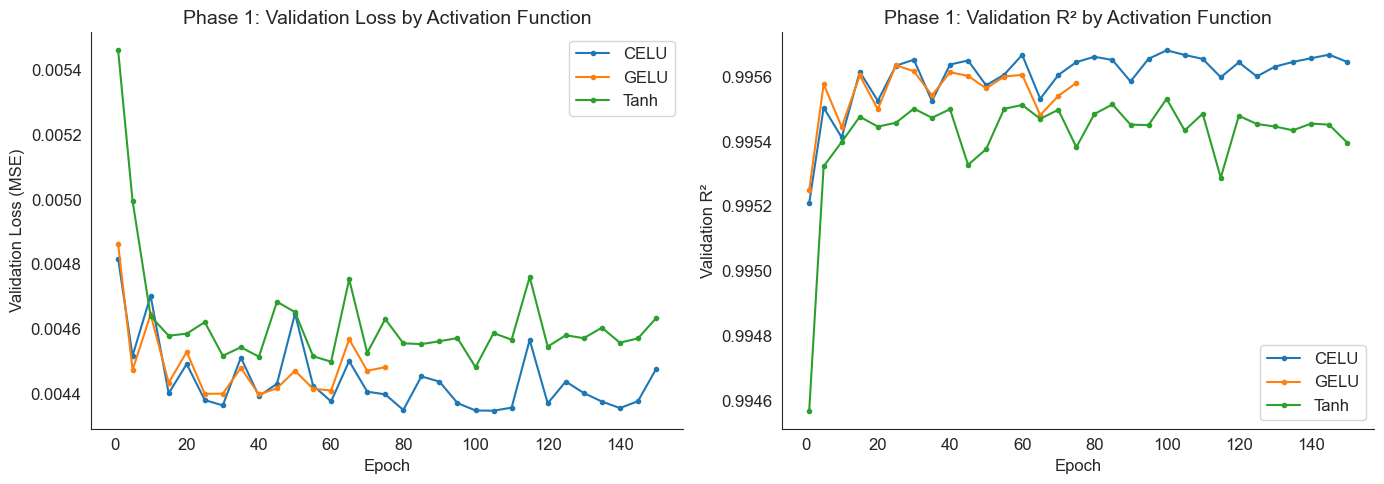

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_phase1_activation_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for act_name, res in phase1_results.items():
    axes[0].plot(res['val_epochs'], res['val_losses'], label=act_name, marker='o', markersize=3)
    axes[1].plot(res['val_epochs'], res['val_r2s'], label=act_name, marker='o', markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Phase 1: Validation Loss by Activation Function')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation R²')
axes[1].set_title('Phase 1: Validation R² by Activation Function')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_phase1_activation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_phase1_activation_comparison.png')

### Phase 2: Learning Rate Comparison

In [12]:
print('=' * 70)
print('PHASE 2: LEARNING RATE COMPARISON')
print(f'Fixed: activation={best_activation}, batch_size=256, optimiser=Adam')
print(f'Validation every {VAL_EVERY} epochs, patience={PATIENCE} val checks')
print('=' * 70)

lr_candidates = [0.01, 0.001, 0.0005, 0.0001]
phase2_results = {}

for lr_val in lr_candidates:
    lr_label = f'{lr_val}'
    print(f'\n--- Training with lr={lr_val} ---')
    torch.manual_seed(SEED)
    model = FunnelDNN(input_dim=22, activation=best_activation)
    result = train_model(
        model, X_train_t, y_train_t, X_val_t, y_val_t,
        optimiser_cls=optim.Adam, lr=lr_val, batch_size=256,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, val_every=VAL_EVERY,
        verbose=True
    )
    phase2_results[lr_label] = result

comparison_results['Phase 2: Learning Rate'] = phase2_results

# Summary
print('\n' + '=' * 70)
print('PHASE 2 SUMMARY')
print(f'{"Learning Rate":<15} {"Best Epoch":>10} {"Val R²":>10} {"Time (s)":>10}')
print('-' * 45)
for lr_label, res in phase2_results.items():
    print(f'{lr_label:<15} {res["best_epoch"]:>10d} {res["best_val_r2"]:>10.6f} {res["elapsed"]:>10.1f}')

best_lr_label = max(phase2_results, key=lambda k: phase2_results[k]['best_val_r2'])
best_lr = float(best_lr_label)
print(f'\n>>> Best learning rate: {best_lr} '
      f'(Val R² = {phase2_results[best_lr_label]["best_val_r2"]:.6f})')

PHASE 2: LEARNING RATE COMPARISON
Fixed: activation=CELU, batch_size=256, optimiser=Adam
Validation every 5 epochs, patience=10 val checks

--- Training with lr=0.01 ---


Epoch   1/200 [VAL] | Train Loss: 0.007795 | Val Loss: 0.008178 | Train R²: 0.993547 | Val R²: 0.993548


Epoch   5/200 [VAL] | Train Loss: 0.005153 | Val Loss: 0.004947 | Train R²: 0.995371 | Val R²: 0.995378


Epoch  10/200 [VAL] | Train Loss: 0.005259 | Val Loss: 0.004559 | Train R²: 0.995458 | Val R²: 0.995453


Epoch  15/200 [VAL] | Train Loss: 1.000114 | Val Loss: 1.002728 | Train R²: 0.000000 | Val R²: 0.000001


...

Epoch 130/200 [VAL] | Train Loss: 0.004304 | Val Loss: 0.004341 | Train R²: 0.995721 | Val R²: 0.995680


Epoch 135/200 [VAL] | Train Loss: 0.004306 | Val Loss: 0.004377 | Train R²: 0.995705 | Val R²: 0.995665


Epoch 140/200 [VAL] | Train Loss: 0.004301 | Val Loss: 0.004330 | Train R²: 0.995724 | Val R²: 0.995683


Epoch 145/200 [VAL] | Train Loss: 0.004304 | Val Loss: 0.004351 | Train R²: 0.995710 | Val R²: 0.995663


Epoch 150/200 [VAL] | Train Loss: 0.004300 | Val Loss: 0.004338 | Train R²: 0.995720 | Val R²: 0.995675

Early stopping after 10 val checks without improvement (epoch 150). Best epoch: 100 with Val R²: 0.995686

Training complete in 556.0s. Best epoch: 100, Best Val R²: 0.995686

PHASE 2 SUMMARY
Learning Rate   Best Epoch     Val R²   Time (s)
---------------------------------------------
0.01                    10   0.995453      222.9
0.001                  100   0.995682      558.1
0.0005                 100   0.995692      563.8
0.0001                 100   0.995686      556.0

>>> Best learning rate: 0.0005 (Val R² = 0.995692)


### Phase 2 - Training Curves Comparison

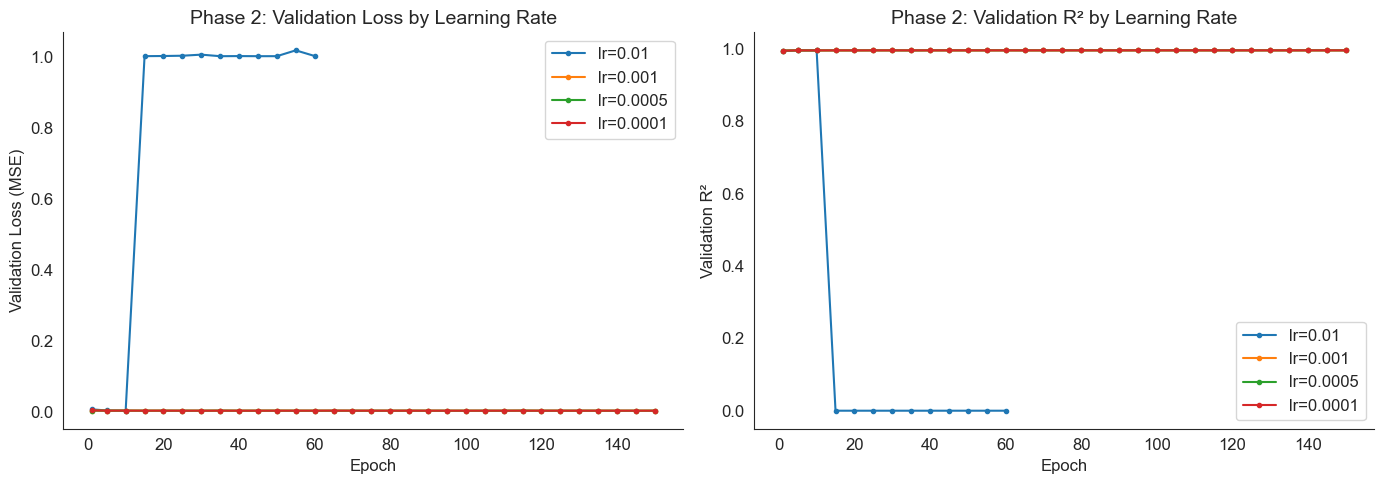

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_phase2_lr_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr_label, res in phase2_results.items():
    axes[0].plot(res['val_epochs'], res['val_losses'], label=f'lr={lr_label}', marker='o', markersize=3)
    axes[1].plot(res['val_epochs'], res['val_r2s'], label=f'lr={lr_label}', marker='o', markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Phase 2: Validation Loss by Learning Rate')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation R²')
axes[1].set_title('Phase 2: Validation R² by Learning Rate')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_phase2_lr_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_phase2_lr_comparison.png')

### Phase 3: Batch Size Comparison

In [14]:
print('=' * 70)
print('PHASE 3: BATCH SIZE COMPARISON')
print(f'Fixed: activation={best_activation}, lr={best_lr}, optimiser=Adam')
print(f'Validation every {VAL_EVERY} epochs, patience={PATIENCE} val checks')
print('=' * 70)

batch_candidates = [64, 128, 256, 512]
phase3_results = {}

for bs in batch_candidates:
    bs_label = str(bs)
    print(f'\n--- Training with batch_size={bs} ---')
    torch.manual_seed(SEED)
    model = FunnelDNN(input_dim=22, activation=best_activation)
    result = train_model(
        model, X_train_t, y_train_t, X_val_t, y_val_t,
        optimiser_cls=optim.Adam, lr=best_lr, batch_size=bs,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, val_every=VAL_EVERY,
        verbose=True
    )
    phase3_results[bs_label] = result

comparison_results['Phase 3: Batch Size'] = phase3_results

# Summary
print('\n' + '=' * 70)
print('PHASE 3 SUMMARY')
print(f'{"Batch Size":<12} {"Best Epoch":>10} {"Val R²":>10} {"Time (s)":>10}')
print('-' * 42)
for bs_label, res in phase3_results.items():
    print(f'{bs_label:<12} {res["best_epoch"]:>10d} {res["best_val_r2"]:>10.6f} {res["elapsed"]:>10.1f}')

best_bs_label = max(phase3_results, key=lambda k: phase3_results[k]['best_val_r2'])
best_bs = int(best_bs_label)
print(f'\n>>> Best batch size: {best_bs} '
      f'(Val R² = {phase3_results[best_bs_label]["best_val_r2"]:.6f})')

PHASE 3: BATCH SIZE COMPARISON
Fixed: activation=CELU, lr=0.0005, optimiser=Adam
Validation every 5 epochs, patience=10 val checks

--- Training with batch_size=64 ---


Epoch   1/200 [VAL] | Train Loss: 0.007976 | Val Loss: 0.004852 | Train R²: 0.995254 | Val R²: 0.995274


Epoch   5/200 [VAL] | Train Loss: 0.004624 | Val Loss: 0.004655 | Train R²: 0.995450 | Val R²: 0.995444


Epoch  10/200 [VAL] | Train Loss: 0.004527 | Val Loss: 0.004470 | Train R²: 0.995549 | Val R²: 0.995548


Epoch  15/200 [VAL] | Train Loss: 0.004479 | Val Loss: 0.004849 | Train R²: 0.995426 | Val R²: 0.995423


...

Epoch 180/200 [VAL] | Train Loss: 0.004306 | Val Loss: 0.004367 | Train R²: 0.995717 | Val R²: 0.995655


Epoch 185/200 [VAL] | Train Loss: 0.004297 | Val Loss: 0.004369 | Train R²: 0.995717 | Val R²: 0.995643


Epoch 190/200 [VAL] | Train Loss: 0.004299 | Val Loss: 0.004359 | Train R²: 0.995736 | Val R²: 0.995661


Epoch 195/200 [VAL] | Train Loss: 0.004294 | Val Loss: 0.004342 | Train R²: 0.995741 | Val R²: 0.995670


Epoch 200/200 [VAL] | Train Loss: 0.004293 | Val Loss: 0.004367 | Train R²: 0.995725 | Val R²: 0.995646

Training complete in 487.3s. Best epoch: 160, Best Val R²: 0.995685

PHASE 3 SUMMARY
Batch Size   Best Epoch     Val R²   Time (s)
------------------------------------------
64                   75   0.995678     1441.8
128                  30   0.995669      491.9
256                 100   0.995692      580.3
512                 160   0.995685      487.3

>>> Best batch size: 256 (Val R² = 0.995692)


### Phase 3 - Training Curves Comparison

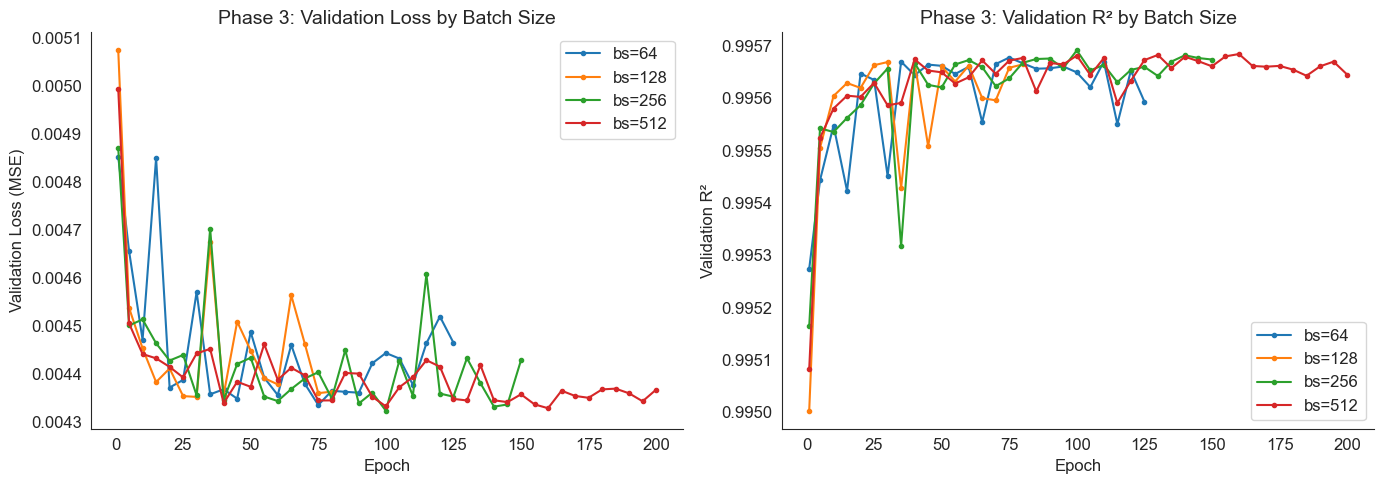

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_phase3_batchsize_comparison.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bs_label, res in phase3_results.items():
    axes[0].plot(res['val_epochs'], res['val_losses'], label=f'bs={bs_label}', marker='o', markersize=3)
    axes[1].plot(res['val_epochs'], res['val_r2s'], label=f'bs={bs_label}', marker='o', markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Phase 3: Validation Loss by Batch Size')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation R²')
axes[1].set_title('Phase 3: Validation R² by Batch Size')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_phase3_batchsize_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_phase3_batchsize_comparison.png')

### Phase 4: Optimiser Comparison (Adam vs NAdam)

In [16]:
print('=' * 70)
print('PHASE 4: OPTIMISER COMPARISON')
print(f'Fixed: activation={best_activation}, lr={best_lr}, batch_size={best_bs}')
print(f'Validation every {VAL_EVERY} epochs, patience={PATIENCE} val checks')
print('=' * 70)

optimiser_candidates = {
    'Adam':  optim.Adam,
    'NAdam': optim.NAdam
}
phase4_results = {}

for opt_name, opt_cls in optimiser_candidates.items():
    print(f'\n--- Training with optimiser: {opt_name} ---')
    torch.manual_seed(SEED)
    model = FunnelDNN(input_dim=22, activation=best_activation)
    result = train_model(
        model, X_train_t, y_train_t, X_val_t, y_val_t,
        optimiser_cls=opt_cls, lr=best_lr, batch_size=best_bs,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, val_every=VAL_EVERY,
        verbose=True
    )
    phase4_results[opt_name] = result

comparison_results['Phase 4: Optimiser'] = phase4_results

# Summary
print('\n' + '=' * 70)
print('PHASE 4 SUMMARY')
print(f'{"Optimiser":<12} {"Best Epoch":>10} {"Val R²":>10} {"Time (s)":>10}')
print('-' * 42)
for opt_name, res in phase4_results.items():
    print(f'{opt_name:<12} {res["best_epoch"]:>10d} {res["best_val_r2"]:>10.6f} {res["elapsed"]:>10.1f}')

best_optimiser_name = max(phase4_results, key=lambda k: phase4_results[k]['best_val_r2'])
best_optimiser_cls = optimiser_candidates[best_optimiser_name]
print(f'\n>>> Best optimiser: {best_optimiser_name} '
      f'(Val R² = {phase4_results[best_optimiser_name]["best_val_r2"]:.6f})')

PHASE 4: OPTIMISER COMPARISON
Fixed: activation=CELU, lr=0.0005, batch_size=256
Validation every 5 epochs, patience=10 val checks

--- Training with optimiser: Adam ---


Epoch   1/200 [VAL] | Train Loss: 0.014634 | Val Loss: 0.004870 | Train R²: 0.995164 | Val R²: 0.995164


Epoch   5/200 [VAL] | Train Loss: 0.004628 | Val Loss: 0.004500 | Train R²: 0.995545 | Val R²: 0.995543


Epoch  10/200 [VAL] | Train Loss: 0.004512 | Val Loss: 0.004513 | Train R²: 0.995538 | Val R²: 0.995536


Epoch  15/200 [VAL] | Train Loss: 0.004459 | Val Loss: 0.004463 | Train R²: 0.995571 | Val R²: 0.995563


...

Epoch 115/200 [VAL] | Train Loss: 0.004306 | Val Loss: 0.004418 | Train R²: 0.995648 | Val R²: 0.995594


Epoch 120/200 [VAL] | Train Loss: 0.004304 | Val Loss: 0.004383 | Train R²: 0.995703 | Val R²: 0.995645


Epoch 125/200 [VAL] | Train Loss: 0.004300 | Val Loss: 0.004363 | Train R²: 0.995711 | Val R²: 0.995649


Epoch 130/200 [VAL] | Train Loss: 0.004296 | Val Loss: 0.004455 | Train R²: 0.995717 | Val R²: 0.995645


Epoch 135/200 [VAL] | Train Loss: 0.004294 | Val Loss: 0.004358 | Train R²: 0.995733 | Val R²: 0.995655

Early stopping after 10 val checks without improvement (epoch 135). Best epoch: 85 with Val R²: 0.995693

Training complete in 582.5s. Best epoch: 85, Best Val R²: 0.995693

PHASE 4 SUMMARY
Optimiser    Best Epoch     Val R²   Time (s)
------------------------------------------
Adam                100   0.995692      562.7
NAdam                85   0.995693      582.5

>>> Best optimiser: NAdam (Val R² = 0.995693)


### Phase 4 - Training Curves Comparison

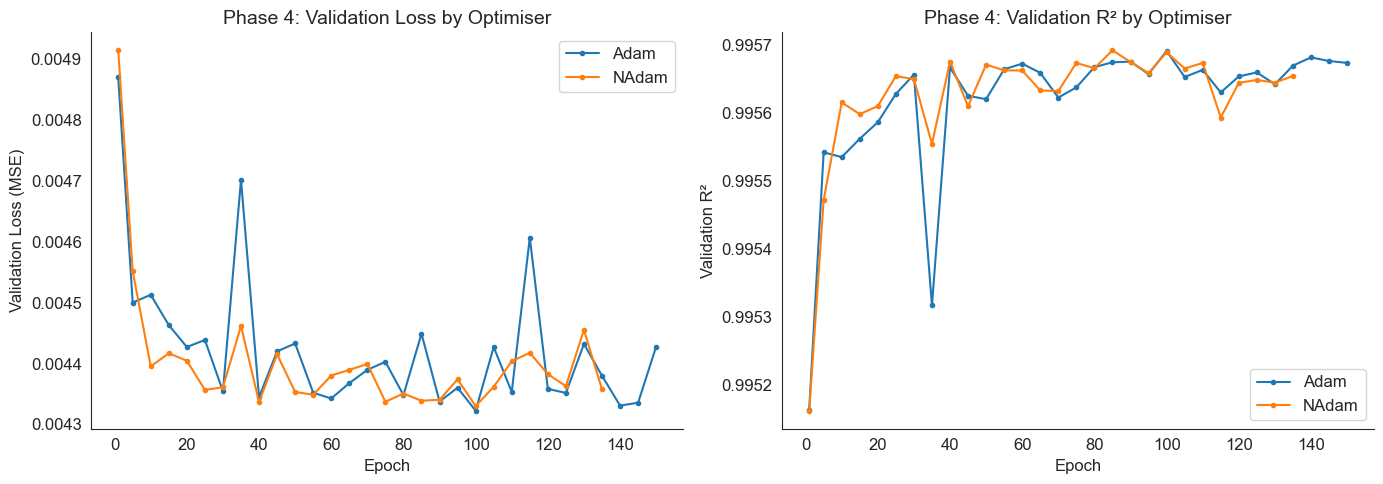

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_phase4_optimiser_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for opt_name, res in phase4_results.items():
    axes[0].plot(res['val_epochs'], res['val_losses'], label=opt_name, marker='o', markersize=3)
    axes[1].plot(res['val_epochs'], res['val_r2s'], label=opt_name, marker='o', markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Phase 4: Validation Loss by Optimiser')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation R²')
axes[1].set_title('Phase 4: Validation R² by Optimiser')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_phase4_optimiser_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_phase4_optimiser_comparison.png')

### Phase 5: Momentum Parameter Comparison (NAdam betas)

The NAdam optimiser uses two exponential decay rates $(\beta_1, \beta_2)$:
- $\beta_1$ controls the first moment (mean) decay rate
- $\beta_2$ controls the second moment (uncentred variance) decay rate

PyTorch default: $(0.9, 0.999)$.  
More conservative (smoother updates): $(0.99, 0.999)$.  
Literature minimum for $\beta_1$: $\approx 0.89$.

Higher $\beta_1$ produces smoother gradient averaging across epochs; being too aggressive (low $\beta_1$) can lead to overfitting on noisy input datasets.

In [18]:
print('=' * 70)
print('PHASE 5: MOMENTUM PARAMETER COMPARISON (NAdam betas)')
print(f'Fixed: activation={best_activation}, lr={best_lr}, batch_size={best_bs}, optimiser={best_optimiser_name}')
print(f'Validation every {VAL_EVERY} epochs, patience={PATIENCE} val checks')
print('=' * 70)

# Momentum candidates: (beta1, beta2)
# Default PyTorch: (0.9, 0.999)
# Moderate: (0.95, 0.999)
# Conservative (supervisor preference): (0.99, 0.999)
momentum_candidates = {
    'B1=0.90 (default)': (0.9, 0.999),
    'B1=0.95 (moderate)': (0.95, 0.999),
    'B1=0.99 (conservative)': (0.99, 0.999),
}

phase5_results = {}

for mom_label, betas_val in momentum_candidates.items():
    print(f'\n--- Training with betas={betas_val} ({mom_label}) ---')
    torch.manual_seed(SEED)
    model = FunnelDNN(input_dim=22, activation=best_activation)
    result = train_model(
        model, X_train_t, y_train_t, X_val_t, y_val_t,
        optimiser_cls=best_optimiser_cls, lr=best_lr, batch_size=best_bs,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, val_every=VAL_EVERY,
        betas=betas_val,
        verbose=True
    )
    phase5_results[mom_label] = result

comparison_results['Phase 5: Momentum'] = phase5_results

# Summary
print('\n' + '=' * 70)
print('PHASE 5 SUMMARY')
print(f'{"Momentum":<28} {"Best Epoch":>10} {"Val R2":>10} {"Time (s)":>10}')
print('-' * 58)
for mom_label, res in phase5_results.items():
    print(f'{mom_label:<28} {res["best_epoch"]:>10d} {res["best_val_r2"]:>10.6f} {res["elapsed"]:>10.1f}')

best_momentum_label = max(phase5_results, key=lambda k: phase5_results[k]['best_val_r2'])
best_betas = momentum_candidates[best_momentum_label]
print(f'\n>>> Best momentum: {best_momentum_label}')
print(f'    betas = {best_betas}')
print(f'    Val R2 = {phase5_results[best_momentum_label]["best_val_r2"]:.6f}')

PHASE 5: MOMENTUM PARAMETER COMPARISON (NAdam betas)
Fixed: activation=CELU, lr=0.0005, batch_size=256, optimiser=NAdam
Validation every 5 epochs, patience=10 val checks

--- Training with betas=(0.9, 0.999) (B1=0.90 (default)) ---


Epoch   1/200 [VAL] | Train Loss: 0.014121 | Val Loss: 0.004915 | Train R²: 0.995150 | Val R²: 0.995163


Epoch   5/200 [VAL] | Train Loss: 0.004560 | Val Loss: 0.004552 | Train R²: 0.995480 | Val R²: 0.995472


Epoch  10/200 [VAL] | Train Loss: 0.004458 | Val Loss: 0.004395 | Train R²: 0.995624 | Val R²: 0.995616


Epoch  15/200 [VAL] | Train Loss: 0.004418 | Val Loss: 0.004417 | Train R²: 0.995610 | Val R²: 0.995599


...

Epoch 125/200 [VAL] | Train Loss: 0.004290 | Val Loss: 0.004377 | Train R²: 0.995701 | Val R²: 0.995641


Epoch 130/200 [VAL] | Train Loss: 0.004288 | Val Loss: 0.004350 | Train R²: 0.995734 | Val R²: 0.995665


Epoch 135/200 [VAL] | Train Loss: 0.004284 | Val Loss: 0.004353 | Train R²: 0.995733 | Val R²: 0.995659


Epoch 140/200 [VAL] | Train Loss: 0.004281 | Val Loss: 0.004373 | Train R²: 0.995742 | Val R²: 0.995659


Epoch 145/200 [VAL] | Train Loss: 0.004275 | Val Loss: 0.004347 | Train R²: 0.995756 | Val R²: 0.995665

Early stopping after 10 val checks without improvement (epoch 145). Best epoch: 95 with Val R²: 0.995685

Training complete in 621.8s. Best epoch: 95, Best Val R²: 0.995685

PHASE 5 SUMMARY
Momentum                     Best Epoch     Val R2   Time (s)
----------------------------------------------------------
B1=0.90 (default)                    85   0.995693      586.6
B1=0.95 (moderate)                   40   0.995690      427.8
B1=0.99 (conservative)               95   0.995685      621.8

>>> Best momentum: B1=0.90 (default)
    betas = (0.9, 0.999)
    Val R2 = 0.995693


### Phase 5 - Momentum Comparison Curves

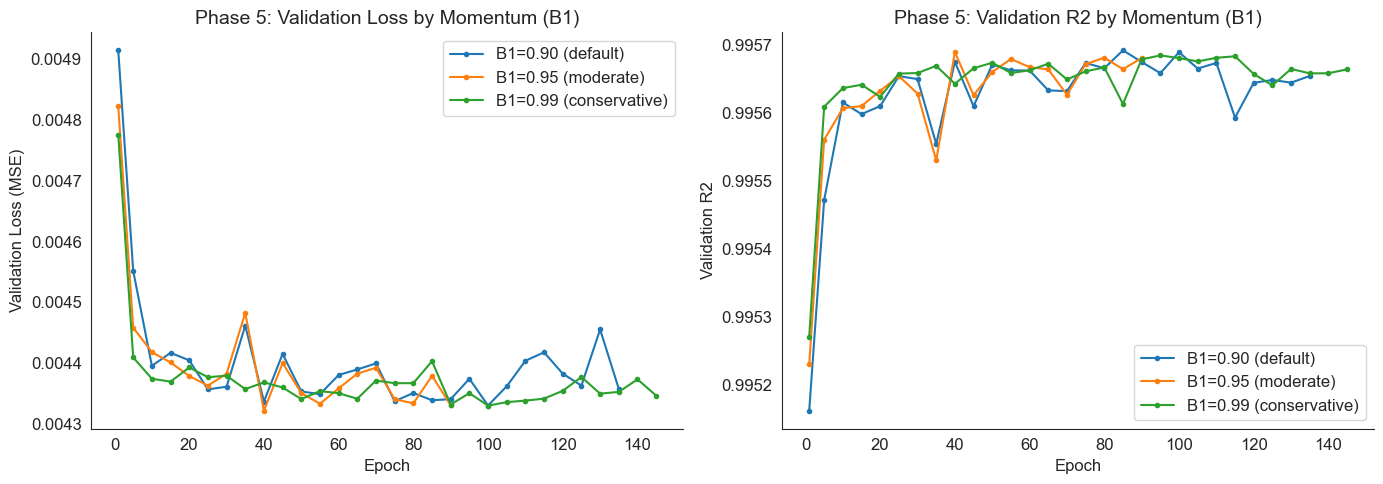

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_phase5_momentum_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mom_label, res in phase5_results.items():
    axes[0].plot(res['val_epochs'], res['val_losses'], label=mom_label, marker='o', markersize=3)
    axes[1].plot(res['val_epochs'], res['val_r2s'], label=mom_label, marker='o', markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Phase 5: Validation Loss by Momentum (B1)')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation R2')
axes[1].set_title('Phase 5: Validation R2 by Momentum (B1)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_phase5_momentum_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_phase5_momentum_comparison.png')

## 10. Grand Comparison Summary

Consolidate all phase results into a single table.

In [20]:
print('=' * 80)
print('GRAND HYPERPARAMETER COMPARISON SUMMARY')
print('=' * 80)
print(f'\nBest activation   : {best_activation}')
print(f'Best learning rate: {best_lr}')
print(f'Best batch size   : {best_bs}')
print(f'Best optimiser    : {best_optimiser_name}')
print(f'Best momentum     : B1={best_betas[0]}, B2={best_betas[1]}')
print()

# Consolidated table
rows = []
for phase_name, phase_res in comparison_results.items():
    for config_name, res in phase_res.items():
        rows.append({
            'Phase': phase_name,
            'Configuration': config_name,
            'Best Epoch': res['best_epoch'],
            'Val R2': round(res['best_val_r2'], 6),
            'Time (s)': round(res['elapsed'], 1)
        })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# Save summary to CSV
summary_path = '/Users/baloyithabangbonganijunior/Downloads/chapter3_hyperparameter_comparison.csv'
df_summary.to_csv(summary_path, index=False)
print(f'\nSummary saved to: {summary_path}')

GRAND HYPERPARAMETER COMPARISON SUMMARY

Best activation   : CELU
Best learning rate: 0.0005
Best batch size   : 256
Best optimiser    : NAdam
Best momentum     : B1=0.9, B2=0.999

                 Phase          Configuration  Best Epoch   Val R2  Time (s)
   Phase 1: Activation                   CELU         100 0.995682     556.7
   Phase 1: Activation                   GELU          25 0.995636     313.8
   Phase 1: Activation                   Tanh         100 0.995532     565.9
Phase 2: Learning Rate                   0.01          10 0.995453     222.9
Phase 2: Learning Rate                  0.001         100 0.995682     558.1
Phase 2: Learning Rate                 0.0005         100 0.995692     563.8
Phase 2: Learning Rate                 0.0001         100 0.995686     556.0
   Phase 3: Batch Size                     64          75 0.995678    1441.8
   Phase 3: Batch Size                    128          30 0.995669     491.9
   Phase 3: Batch Size                    256    

## 11. Final Model Training

Train the final model using the best hyperparameters from all five comparison phases.

In [21]:
print('=' * 70)
print('FINAL MODEL TRAINING')
print(f'Architecture : 22 -> 256 -> 128 -> 64 -> 32 -> 16 -> 1')
print(f'Activation   : {best_activation}')
print(f'Learning rate: {best_lr}')
print(f'Batch size   : {best_bs}')
print(f'Optimiser    : {best_optimiser_name}')
print(f'Momentum     : B1={best_betas[0]}, B2={best_betas[1]}')
print(f'Max epochs   : {MAX_EPOCHS}')
print(f'Val every    : {VAL_EVERY} epochs')
print(f'Patience     : {PATIENCE} val checks')
print('=' * 70)

torch.manual_seed(SEED)
final_model = FunnelDNN(input_dim=22, activation=best_activation)

final_result = train_model(
    final_model, X_train_t, y_train_t, X_val_t, y_val_t,
    optimiser_cls=best_optimiser_cls, lr=best_lr, batch_size=best_bs,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, val_every=VAL_EVERY,
    betas=best_betas,
    verbose=True
)

# Load best model state
final_model.load_state_dict(final_result['best_model_state'])
final_model = final_model.to(DEVICE)
final_model.eval()

print(f'\nFinal model loaded from epoch {final_result["best_epoch"]}')

FINAL MODEL TRAINING
Architecture : 22 -> 256 -> 128 -> 64 -> 32 -> 16 -> 1
Activation   : CELU
Learning rate: 0.0005
Batch size   : 256
Optimiser    : NAdam
Momentum     : B1=0.9, B2=0.999
Max epochs   : 200
Val every    : 5 epochs
Patience     : 10 val checks


Epoch   1/200 [VAL] | Train Loss: 0.014121 | Val Loss: 0.004915 | Train R²: 0.995150 | Val R²: 0.995163


Epoch   5/200 [VAL] | Train Loss: 0.004560 | Val Loss: 0.004552 | Train R²: 0.995480 | Val R²: 0.995472


Epoch  10/200 [VAL] | Train Loss: 0.004458 | Val Loss: 0.004395 | Train R²: 0.995624 | Val R²: 0.995616


Epoch  15/200 [VAL] | Train Loss: 0.004418 | Val Loss: 0.004417 | Train R²: 0.995610 | Val R²: 0.995599


...

Epoch 115/200 [VAL] | Train Loss: 0.004306 | Val Loss: 0.004418 | Train R²: 0.995648 | Val R²: 0.995594


Epoch 120/200 [VAL] | Train Loss: 0.004304 | Val Loss: 0.004383 | Train R²: 0.995703 | Val R²: 0.995645


Epoch 125/200 [VAL] | Train Loss: 0.004300 | Val Loss: 0.004363 | Train R²: 0.995711 | Val R²: 0.995649


Epoch 130/200 [VAL] | Train Loss: 0.004296 | Val Loss: 0.004455 | Train R²: 0.995717 | Val R²: 0.995645


Epoch 135/200 [VAL] | Train Loss: 0.004294 | Val Loss: 0.004358 | Train R²: 0.995733 | Val R²: 0.995655

Early stopping after 10 val checks without improvement (epoch 135). Best epoch: 85 with Val R²: 0.995693

Training complete in 583.8s. Best epoch: 85, Best Val R²: 0.995693

Final model loaded from epoch 85


### Training and Validation Curves (Final Model)

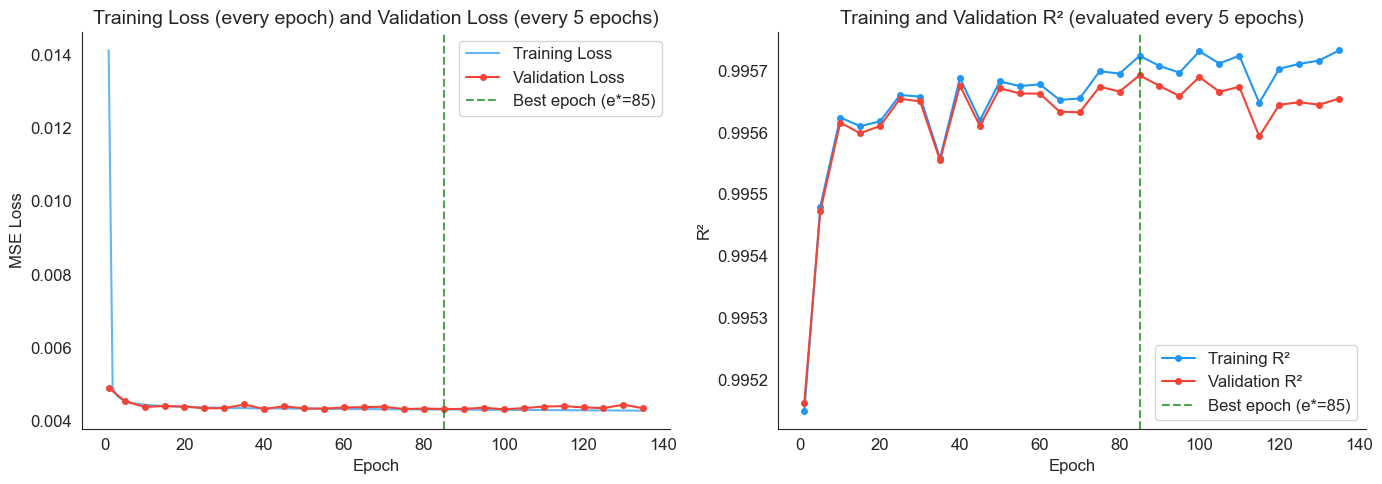

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_training_validation_curves.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_epochs = range(1, len(final_result['train_losses']) + 1)

# (Left) Loss: training loss every epoch, validation loss only at val_epochs
axes[0].plot(all_epochs, final_result['train_losses'], label='Training Loss', color='#2196F3', alpha=0.7)
axes[0].plot(final_result['val_epochs'], final_result['val_losses'],
             label='Validation Loss', color='#F44336', marker='o', markersize=4)
axes[0].axvline(x=final_result['best_epoch'], color='green', linestyle='--', alpha=0.7,
                label=f'Best epoch (e*={final_result["best_epoch"]})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss (every epoch) and Validation Loss (every 5 epochs)')
axes[0].legend()
sns.despine(ax=axes[0])

# (Right) R²: only at validation epochs
axes[1].plot(final_result['val_epochs'], final_result['train_r2s'],
             label='Training R²', color='#2196F3', marker='o', markersize=4)
axes[1].plot(final_result['val_epochs'], final_result['val_r2s'],
             label='Validation R²', color='#F44336', marker='o', markersize=4)
axes[1].axvline(x=final_result['best_epoch'], color='green', linestyle='--', alpha=0.7,
                label=f'Best epoch (e*={final_result["best_epoch"]})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].set_title('Training and Validation R² (evaluated every 5 epochs)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_training_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_training_validation_curves.png')

## 12. Model Evaluation on All Sets (De-normalised Scale)

Evaluate the final model using the standard R² formula on the original Rand scale.

In [23]:
final_model.eval()

with torch.no_grad():
    # Predictions on normalised scale
    preds_train_norm = final_model(X_train_t.to(DEVICE)).cpu()
    preds_val_norm   = final_model(X_val_t.to(DEVICE)).cpu()
    preds_test_norm  = final_model(X_test_t.to(DEVICE)).cpu()
    
    # De-normalise predictions
    preds_train_raw = denormalise(preds_train_norm)
    preds_val_raw   = denormalise(preds_val_norm)
    preds_test_raw  = denormalise(preds_test_norm)

# Metrics on de-normalised (original Rand) scale
metrics = {}
for set_name, y_true, y_pred in [
    ('Train', y_train_raw_t, preds_train_raw),
    ('Validation', y_val_raw_t, preds_val_raw),
    ('Test', y_test_raw_t, preds_test_raw)
]:
    metrics[set_name] = {
        'R²': r2_score(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAE': mae(y_true, y_pred)
    }

print('=' * 60)
print('FINAL MODEL EVALUATION (De-normalised, Rand scale)')
print('=' * 60)
print(f'{"Set":<12} {"R²":>10} {"RMSE (R)":>12} {"MAE (R)":>12}')
print('-' * 46)
for set_name, m in metrics.items():
    print(f'{set_name:<12} {m["R²"]:>10.6f} {m["RMSE"]:>12.2f} {m["MAE"]:>12.2f}')

print(f'\nTest R²: {metrics["Test"]["R²"]:.4f} ({metrics["Test"]["R²"]*100:.2f}%)')

FINAL MODEL EVALUATION (De-normalised, Rand scale)
Set                  R²     RMSE (R)      MAE (R)
----------------------------------------------
Train          0.995705       289.42       250.08
Validation     0.995672       290.88       251.30
Test           0.995643       291.07       251.52

Test R²: 0.9956 (99.56%)


## 13. Diagnostic Plots

### 13.1 Actual vs Predicted - Sorted Line Plot (Training Set)

Observations sorted by actual charges. If the model fits well, the predicted line closely tracks the actual line.

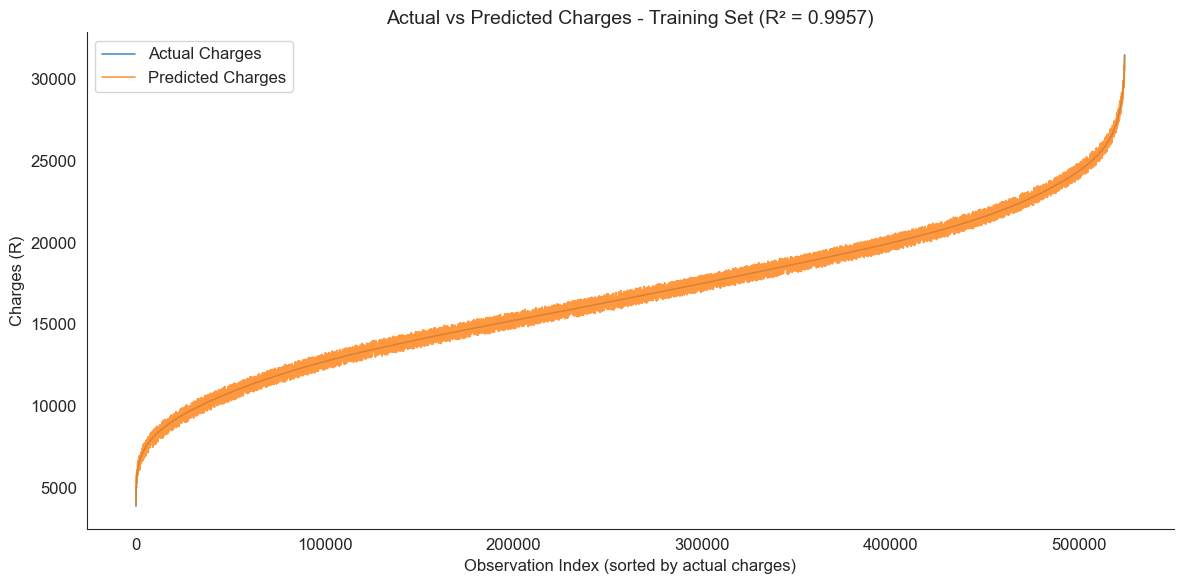

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_actual_vs_predicted_sorted_train.png


In [24]:
# Sorted actual vs predicted (Training Set)
y_act_train = y_train_raw_t.numpy().flatten()
y_prd_train = preds_train_raw.numpy().flatten()

# Sort by actual values
sort_idx = np.argsort(y_act_train)
y_act_sorted = y_act_train[sort_idx]
y_prd_sorted = y_prd_train[sort_idx]

# Subsample for plotting clarity
n_plot = min(10000, len(y_act_sorted))
step = max(1, len(y_act_sorted) // n_plot)
plot_idx = np.arange(0, len(y_act_sorted), step)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_idx, y_act_sorted[plot_idx], color='tab:blue', linewidth=1.2,
        label='Actual Charges', alpha=0.8)
ax.plot(plot_idx, y_prd_sorted[plot_idx], color='tab:orange', linewidth=1.2,
        label='Predicted Charges', alpha=0.8)
ax.set_xlabel('Observation Index (sorted by actual charges)')
ax.set_ylabel('Charges (R)')
ax.set_title(f'Actual vs Predicted Charges - Training Set (R² = {metrics["Train"]["R²"]:.4f})')
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_actual_vs_predicted_sorted_train.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_actual_vs_predicted_sorted_train.png')

### 13.2 Actual vs Predicted - Sorted Line Plot (Test Set)

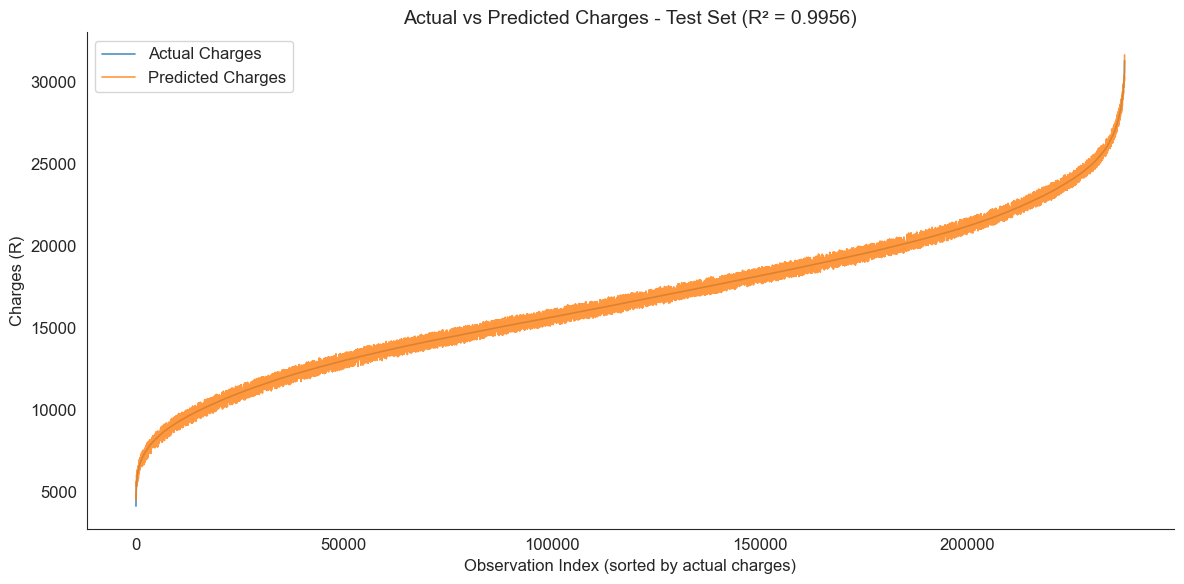

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_actual_vs_predicted_sorted_test.png


In [25]:
# Sorted actual vs predicted (Test Set)
y_act_test = y_test_raw_t.numpy().flatten()
y_prd_test = preds_test_raw.numpy().flatten()

# Sort by actual values
sort_idx = np.argsort(y_act_test)
y_act_sorted = y_act_test[sort_idx]
y_prd_sorted = y_prd_test[sort_idx]

# Subsample for plotting clarity
n_plot = min(10000, len(y_act_sorted))
step = max(1, len(y_act_sorted) // n_plot)
plot_idx = np.arange(0, len(y_act_sorted), step)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_idx, y_act_sorted[plot_idx], color='tab:blue', linewidth=1.2,
        label='Actual Charges', alpha=0.8)
ax.plot(plot_idx, y_prd_sorted[plot_idx], color='tab:orange', linewidth=1.2,
        label='Predicted Charges', alpha=0.8)
ax.set_xlabel('Observation Index (sorted by actual charges)')
ax.set_ylabel('Charges (R)')
ax.set_title(f'Actual vs Predicted Charges - Test Set (R² = {metrics["Test"]["R²"]:.4f})')
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_actual_vs_predicted_sorted_test.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_actual_vs_predicted_sorted_test.png')

### 13.3 Violin Plots: Distribution of Actual vs Predicted Charges

Violin plots compare the distributional shape of actual and predicted charges on training and test sets.  
A well-calibrated model should produce predictions whose distribution closely mirrors the actual distribution.

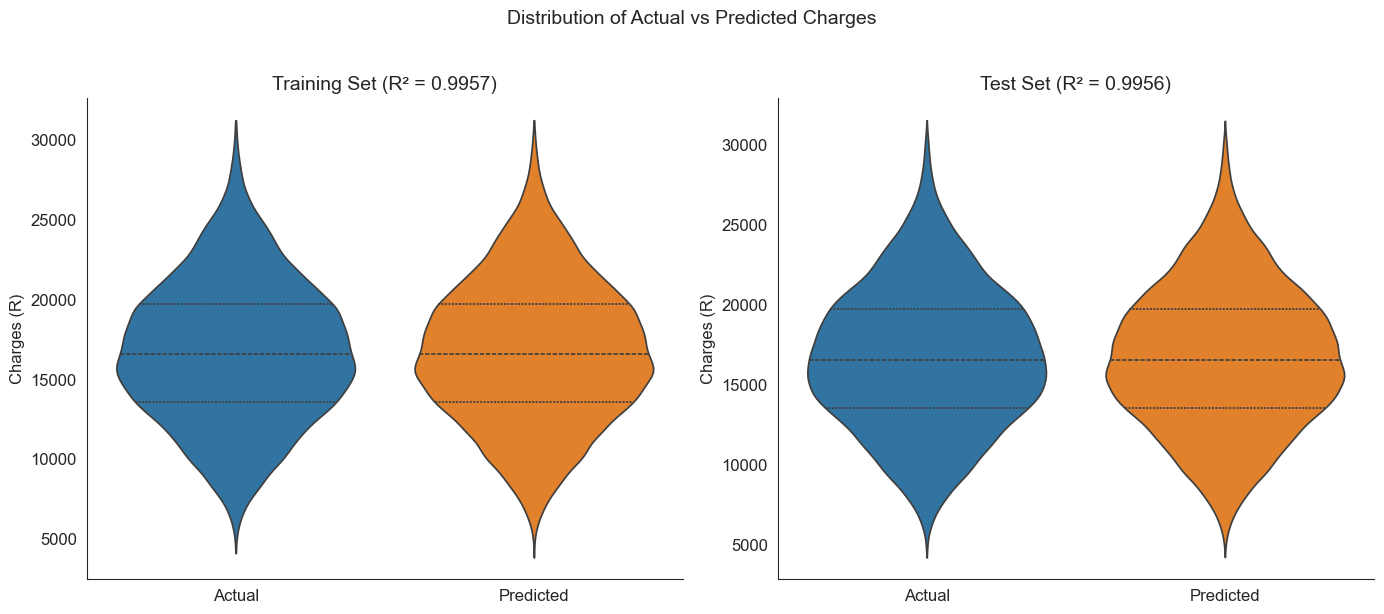

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_violin_actual_vs_predicted.png


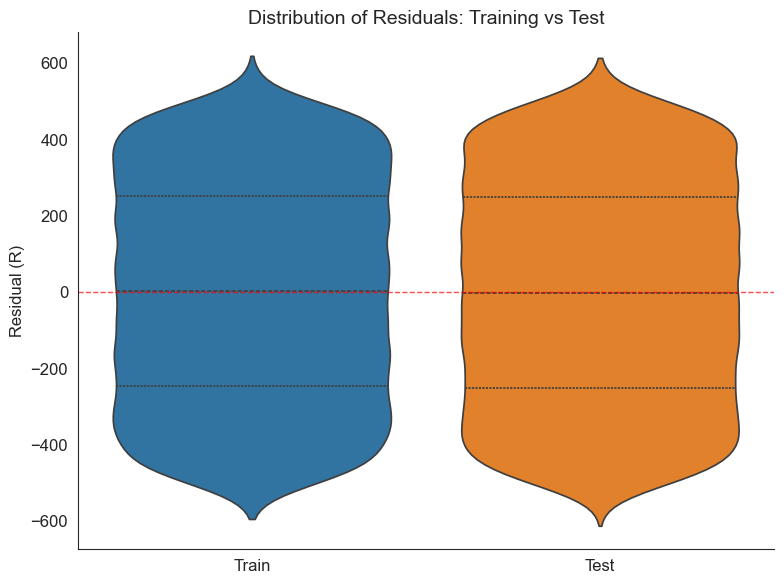

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_violin_residuals.png


In [26]:
# --- Violin Plot: Actual vs Predicted distributions (Training Set) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subsample for violin plots (seaborn can be slow with very large arrays)
n_violin = min(50000, len(y_act_train))
rng = np.random.default_rng(SEED)
v_idx_train = rng.choice(len(y_act_train), n_violin, replace=False)
v_idx_test  = rng.choice(len(y_act_test), min(n_violin, len(y_act_test)), replace=False)

# Training set violin
df_violin_train = pd.DataFrame({
    'Charges (R)': np.concatenate([y_act_train[v_idx_train], y_prd_train[v_idx_train]]),
    'Type': ['Actual'] * len(v_idx_train) + ['Predicted'] * len(v_idx_train)
})
sns.violinplot(data=df_violin_train, x='Type', y='Charges (R)', ax=axes[0],
               palette=['tab:blue', 'tab:orange'], inner='quartile', cut=0)
axes[0].set_title(f'Training Set (R² = {metrics["Train"]["R²"]:.4f})')
axes[0].set_xlabel('')
sns.despine(ax=axes[0])

# Test set violin
df_violin_test = pd.DataFrame({
    'Charges (R)': np.concatenate([y_act_test[v_idx_test], y_prd_test[v_idx_test]]),
    'Type': ['Actual'] * len(v_idx_test) + ['Predicted'] * len(v_idx_test)
})
sns.violinplot(data=df_violin_test, x='Type', y='Charges (R)', ax=axes[1],
               palette=['tab:blue', 'tab:orange'], inner='quartile', cut=0)
axes[1].set_title(f'Test Set (R² = {metrics["Test"]["R²"]:.4f})')
axes[1].set_xlabel('')
sns.despine(ax=axes[1])

plt.suptitle('Distribution of Actual vs Predicted Charges', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_violin_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_violin_actual_vs_predicted.png')

# --- Violin Plot: Residual distributions (Training vs Test) ---
residuals_train = (y_act_train - y_prd_train)
residuals_test_arr = (y_act_test - y_prd_test)

df_violin_resid = pd.DataFrame({
    'Residual (R)': np.concatenate([residuals_train[v_idx_train], residuals_test_arr[v_idx_test]]),
    'Set': ['Train'] * len(v_idx_train) + ['Test'] * len(v_idx_test)
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df_violin_resid, x='Set', y='Residual (R)', ax=ax,
               palette=['tab:blue', 'tab:orange'], inner='quartile', cut=0)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Distribution of Residuals: Training vs Test')
ax.set_xlabel('')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_violin_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_violin_residuals.png')

### 13.4 Residual Diagnostics (Test Set)

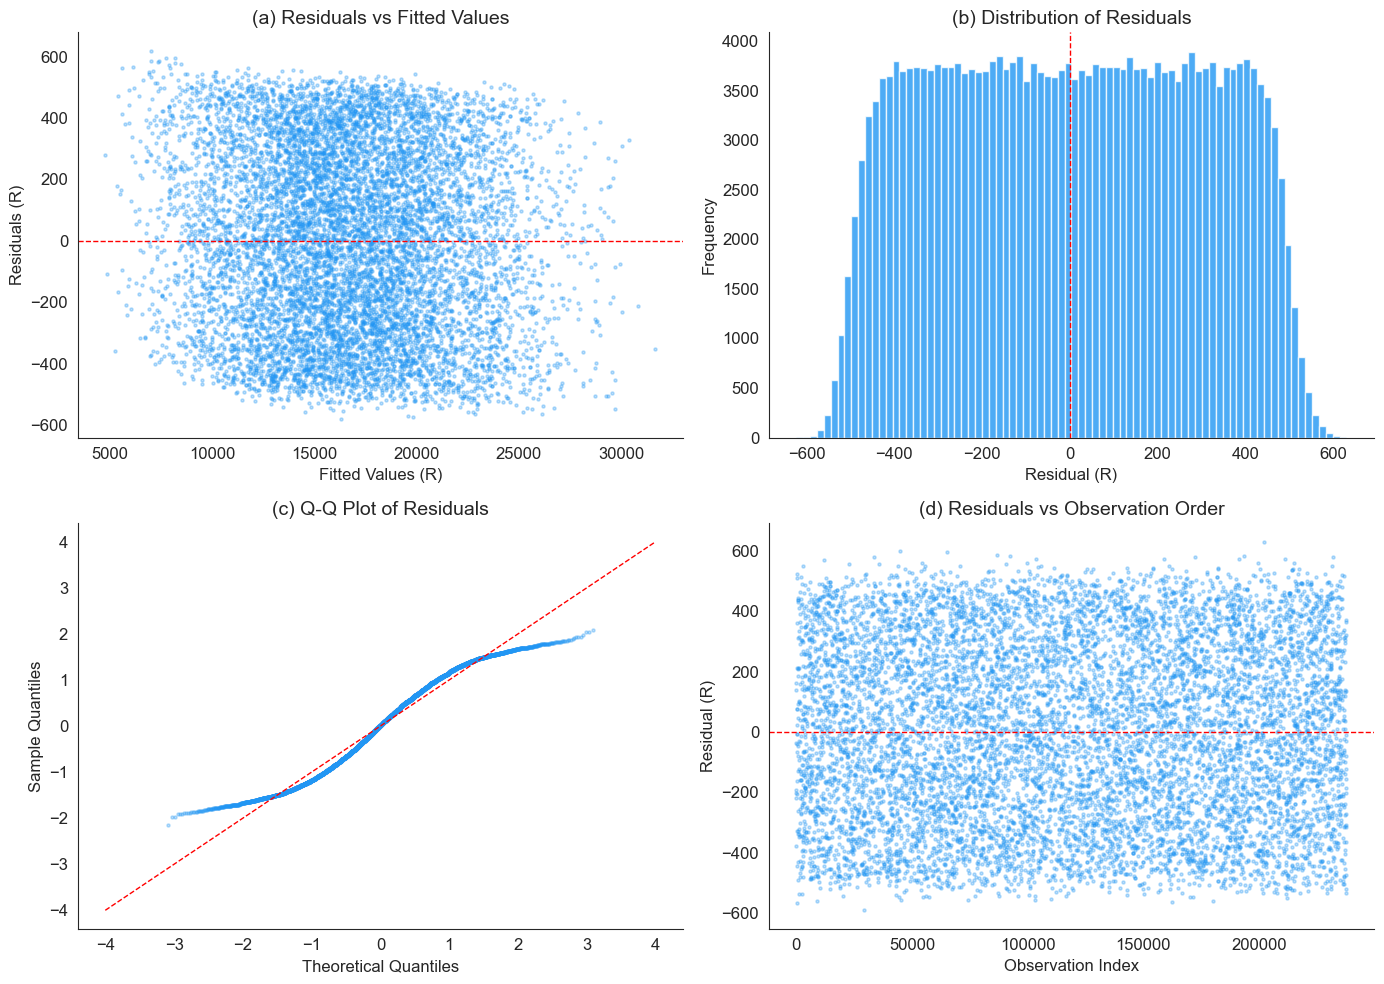

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_residual_diagnostics.png

Residual Summary (Test Set):
  Mean     : 1.34
  Std Dev  : 291.07
  Skewness : 0.0012
  Kurtosis : -1.1637


In [27]:
# Full test set residuals
residuals_test = (y_test_raw_t - preds_test_raw).numpy().flatten()
fitted_test    = preds_test_raw.numpy().flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subsample for scatter plots
n_plot = min(10000, len(residuals_test))
idx = np.random.choice(len(residuals_test), n_plot, replace=False)

# (a) Residuals vs Fitted
axes[0, 0].scatter(fitted_test[idx], residuals_test[idx], alpha=0.3, s=5, color='#2196F3')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values (R)')
axes[0, 0].set_ylabel('Residuals (R)')
axes[0, 0].set_title('(a) Residuals vs Fitted Values')
sns.despine(ax=axes[0, 0])

# (b) Histogram of Residuals
axes[0, 1].hist(residuals_test, bins=80, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Residual (R)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('(b) Distribution of Residuals')
sns.despine(ax=axes[0, 1])

# (c) QQ Plot of Residuals
from scipy import stats
standardised_res = (residuals_test - residuals_test.mean()) / residuals_test.std()
qq_sample = np.random.choice(standardised_res, min(5000, len(standardised_res)), replace=False)
qq_sample.sort()
theoretical = stats.norm.ppf(np.linspace(0.001, 0.999, len(qq_sample)))
axes[1, 0].scatter(theoretical, qq_sample, alpha=0.3, s=5, color='#2196F3')
axes[1, 0].plot([-4, 4], [-4, 4], 'r--', linewidth=1)
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')
axes[1, 0].set_title('(c) Q-Q Plot of Residuals')
sns.despine(ax=axes[1, 0])

# (d) Residuals vs Observation Index (check for patterns)
idx_seq = np.random.choice(len(residuals_test), n_plot, replace=False)
idx_seq.sort()
axes[1, 1].scatter(idx_seq, residuals_test[idx_seq], alpha=0.3, s=5, color='#2196F3')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel('Residual (R)')
axes[1, 1].set_title('(d) Residuals vs Observation Order')
sns.despine(ax=axes[1, 1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_residual_diagnostics.png')

# Residual summary statistics
print(f'\nResidual Summary (Test Set):')
print(f'  Mean     : {residuals_test.mean():.2f}')
print(f'  Std Dev  : {residuals_test.std():.2f}')
print(f'  Skewness : {stats.skew(residuals_test):.4f}')
print(f'  Kurtosis : {stats.kurtosis(residuals_test):.4f}')

### 13.5 Principal Component Structural Diagnostics

PCA is used as a structural diagnostic of the normalised model-ready input space.  
It is **not** used for dimension reduction; no predictors are removed.

**Purpose 1:** Project training and test observations onto the same principal component space.  
Similar point-cloud structure across partitions supports the view that the data partition has not introduced a major structural shift.

**Purpose 2:** Display the same PC coordinates using observed and predicted colourings.  
Similar colour patterns indicate that the fitted DNN has captured the main target structure.

Four diagnostic figures are produced:
1. **Train PCA, Actual Target** - normalised inputs coloured by observed charges
2. **Train PCA, Predicted Value** - normalised inputs coloured by model predictions
3. **Test PCA, Actual Target** - normalised inputs coloured by observed charges
4. **Test PCA, Predicted Value** - normalised inputs coloured by model predictions

## Validation Analysis

### Figure 5: Analysis of Validation Loss Across Various Hyperparameter Combinations

Explained variance ratio: PC1=6.8%, PC2=6.1%
Cumulative: 12.9%


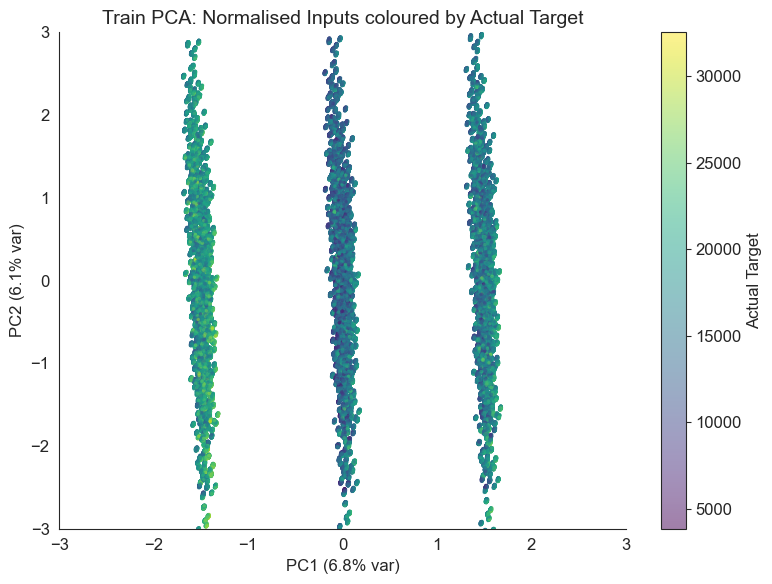

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_pca_train_actual.png


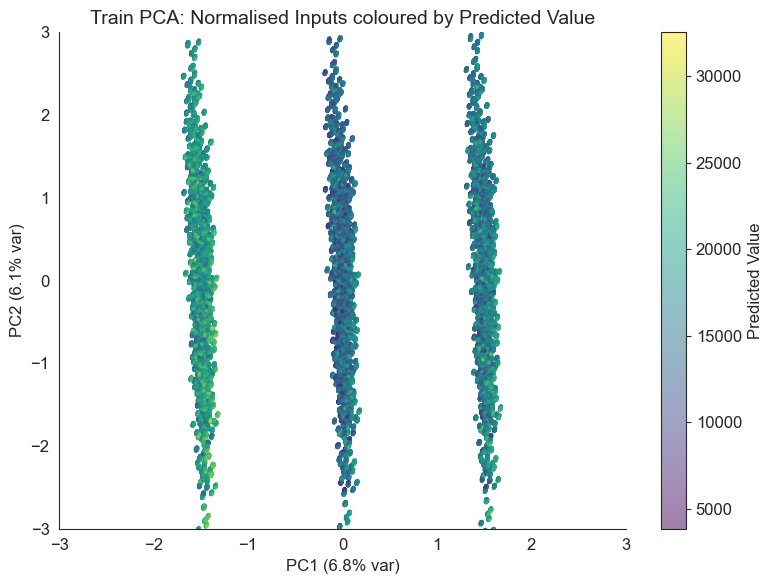

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_pca_train_predicted.png


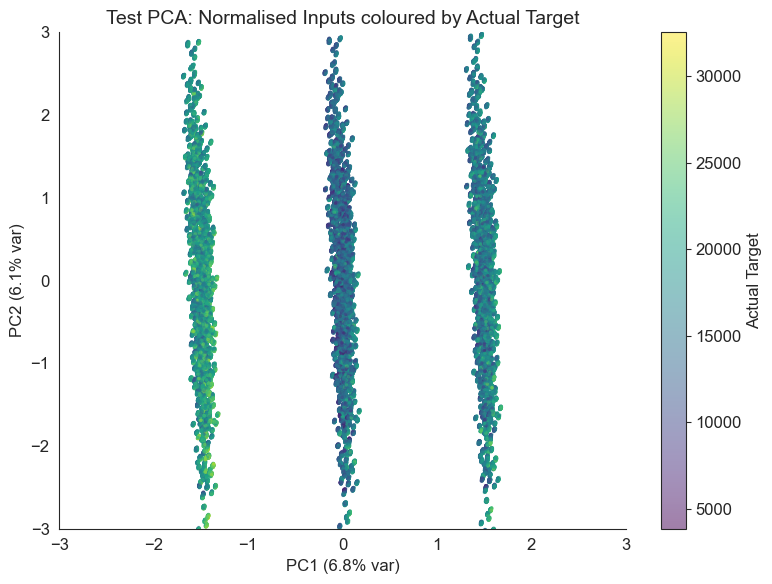

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_pca_test_actual.png


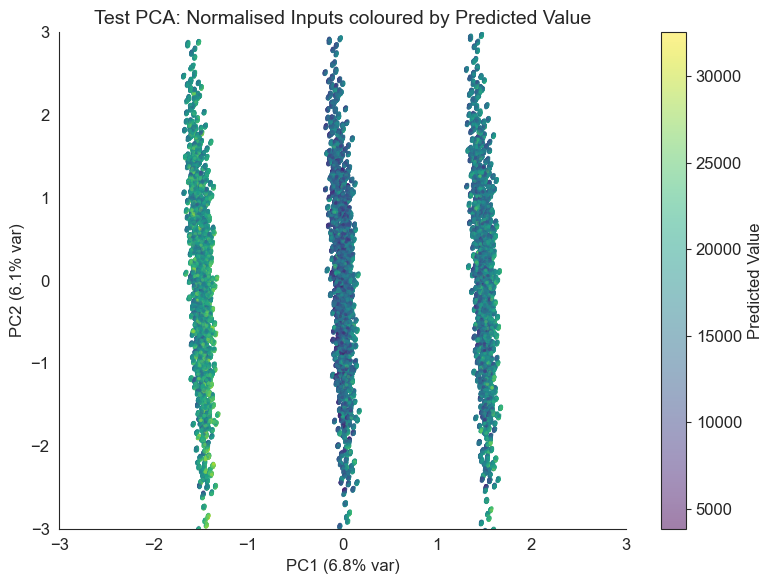

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_pca_test_predicted.png

PCA Loadings (top features by absolute loading on PC1 and PC2):

PC1 top loadings:
                                                 PC1
coverage_level_Standard                     0.706060
coverage_level_Premium                     -0.705973
occupation_White_collar                    -0.030472
occupation_Blue_collar                      0.025085
medical_history_Diabetes                    0.017468
family_medical_history_High_blood_pressure -0.016703
family_medical_history_Heart_disease        0.016683
region_southwest                           -0.014698

PC2 top loadings:
                                           PC2
occupation_White_collar               0.438358
region_southeast                     -0.422301
occupation_Student                   -0.351755
exercise_frequency_Never             -0.327159
region_northwest                      0.291910
exercise_frequency_Occasionally       0.282

In [28]:
from sklearn.decomposition import PCA

# --- PCA on the standardised model-ready input space ---
# Fit on training set, project train and test partitions
pca = PCA(n_components=2, random_state=SEED)
pca.fit(X_train)

pc_train = pca.transform(X_train)
pc_test  = pca.transform(X_test)

ev1 = pca.explained_variance_ratio_[0] * 100  # PC1 variance %
ev2 = pca.explained_variance_ratio_[1] * 100  # PC2 variance %

print(f'Explained variance ratio: PC1={ev1:.1f}%, PC2={ev2:.1f}%')
print(f'Cumulative: {ev1 + ev2:.1f}%')

# De-normalised actual and predicted values (from final best model)
y_act_train = y_train_raw_t.numpy().flatten()
y_prd_train = preds_train_raw.numpy().flatten()
y_act_test  = y_test_raw_t.numpy().flatten()
y_prd_test  = preds_test_raw.numpy().flatten()

# Shared colour limits across all four plots for consistent comparison
vmin = min(y_act_train.min(), y_act_test.min(), y_prd_train.min(), y_prd_test.min())
vmax = max(y_act_train.max(), y_act_test.max(), y_prd_train.max(), y_prd_test.max())

# Axis limits (fixed range for consistency)
axis_lim = 3

# --- Helper function for individual PCA scatter plots ---
def plot_pca_scatter(pc_coords, colour_values, title, cbar_label, save_name):
    """Create a single PCA scatter plot matching the reference style."""
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        pc_coords[:, 0], pc_coords[:, 1],
        c=colour_values, cmap='viridis', s=6, alpha=0.5,
        vmin=vmin, vmax=vmax, edgecolors='none'
    )
    ax.set_xlim(-axis_lim, axis_lim)
    ax.set_ylim(-axis_lim, axis_lim)
    ax.set_xlabel(f'PC1 ({ev1:.1f}% var)')
    ax.set_ylabel(f'PC2 ({ev2:.1f}% var)')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label=cbar_label)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(FIG_DIR + save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_DIR}{save_name}')


# --- Figure 1: Train PCA coloured by Actual Target ---
plot_pca_scatter(
    pc_train, y_act_train,
    title='Train PCA: Normalised Inputs coloured by Actual Target',
    cbar_label='Actual Target',
    save_name='fig_pca_train_actual.png'
)

# --- Figure 2: Train PCA coloured by Predicted Value ---
plot_pca_scatter(
    pc_train, y_prd_train,
    title='Train PCA: Normalised Inputs coloured by Predicted Value',
    cbar_label='Predicted Value',
    save_name='fig_pca_train_predicted.png'
)

# --- Figure 3: Test PCA coloured by Actual Target ---
plot_pca_scatter(
    pc_test, y_act_test,
    title='Test PCA: Normalised Inputs coloured by Actual Target',
    cbar_label='Actual Target',
    save_name='fig_pca_test_actual.png'
)

# --- Figure 4: Test PCA coloured by Predicted Value ---
plot_pca_scatter(
    pc_test, y_prd_test,
    title='Test PCA: Normalised Inputs coloured by Predicted Value',
    cbar_label='Predicted Value',
    save_name='fig_pca_test_predicted.png'
)

# --- PCA loading inspection ---
print('\nPCA Loadings (top features by absolute loading on PC1 and PC2):')
loadings = pd.DataFrame(pca.components_.T, index=FEATURES,
                         columns=['PC1', 'PC2'])
loadings['|PC1|'] = loadings['PC1'].abs()
loadings['|PC2|'] = loadings['PC2'].abs()
print('\nPC1 top loadings:')
print(loadings.sort_values('|PC1|', ascending=False)[['PC1']].head(8).to_string())
print('\nPC2 top loadings:')
print(loadings.sort_values('|PC2|', ascending=False)[['PC2']].head(8).to_string())

### 13.6 PCA Loadings

The PCA loading vectors $\mathbf{w}_1, \mathbf{w}_2 \in \mathbb{R}^{22}$ describe how each standardised input feature contributes to the first two principal components.  
A large absolute loading indicates that the feature strongly influences the direction of variation captured by that component.

Two visualisations are provided:
1. **Horizontal bar charts** of all 22 feature loadings on PC1 and PC2, sorted by absolute magnitude.
2. **Full loadings table** printed and saved to CSV for reference in the dissertation text.

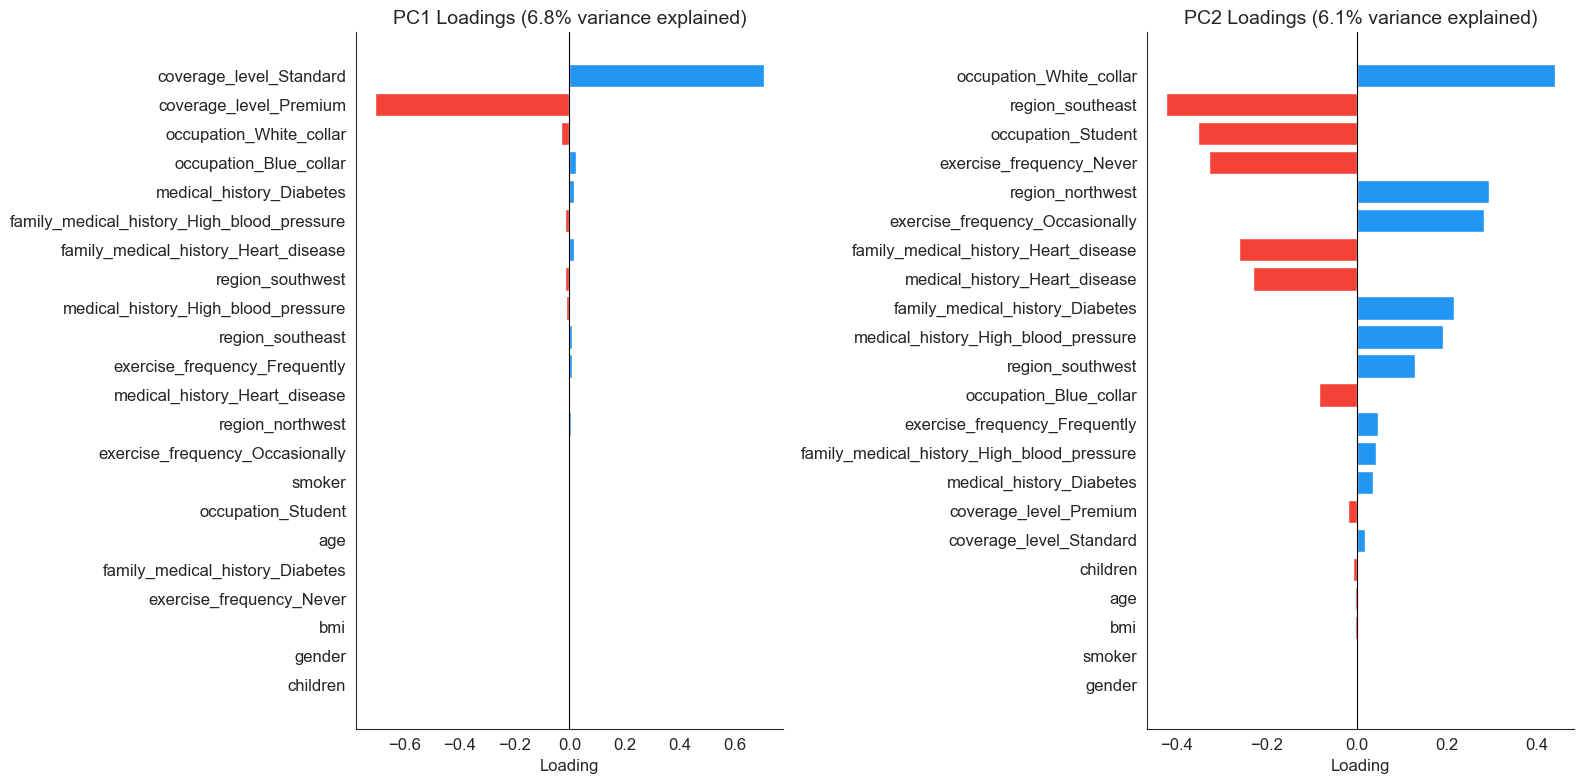

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_pca_loadings.png

FULL PCA LOADINGS TABLE (sorted by |PC1|)
Feature                                       PC1      PC2
--------------------------------------------------------
coverage_level_Standard                    0.7061   0.0181
coverage_level_Premium                    -0.7060  -0.0195
occupation_White_collar                   -0.0305   0.4384
occupation_Blue_collar                     0.0251  -0.0846
medical_history_Diabetes                   0.0175   0.0353
family_medical_history_High_blood_pressure  -0.0167   0.0431
family_medical_history_Heart_disease       0.0167  -0.2607
region_southwest                          -0.0147   0.1292
medical_history_High_blood_pressure       -0.0132   0.1918
region_southeast                           0.0096  -0.4223
exercise_frequency_Frequently              0.0083   0.0460
medical_history_Heart_disease             -0.0053  -0.2302
region_northwest                          

In [29]:
# --- Build full loadings DataFrame (reuse from cell above) ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2']
)

# --- (a) Horizontal bar chart: PC1 loadings sorted by absolute value ---
loadings_pc1 = loadings[['PC1']].copy()
loadings_pc1['|PC1|'] = loadings_pc1['PC1'].abs()
loadings_pc1 = loadings_pc1.sort_values('|PC1|', ascending=True)  # ascending for barh

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colours_pc1 = ['#2196F3' if v >= 0 else '#F44336' for v in loadings_pc1['PC1']]
axes[0].barh(loadings_pc1.index, loadings_pc1['PC1'], color=colours_pc1, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Loading')
axes[0].set_title(f'PC1 Loadings ({ev1:.1f}% variance explained)')
sns.despine(ax=axes[0])

# --- (b) Horizontal bar chart: PC2 loadings sorted by absolute value ---
loadings_pc2 = loadings[['PC2']].copy()
loadings_pc2['|PC2|'] = loadings_pc2['PC2'].abs()
loadings_pc2 = loadings_pc2.sort_values('|PC2|', ascending=True)

colours_pc2 = ['#2196F3' if v >= 0 else '#F44336' for v in loadings_pc2['PC2']]
axes[1].barh(loadings_pc2.index, loadings_pc2['PC2'], color=colours_pc2, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Loading')
axes[1].set_title(f'PC2 Loadings ({ev2:.1f}% variance explained)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_pca_loadings.png')

# --- Full loadings table (all 22 features, both components) ---
loadings_full = loadings.copy()
loadings_full['|PC1|'] = loadings_full['PC1'].abs()
loadings_full['|PC2|'] = loadings_full['PC2'].abs()
loadings_full = loadings_full.sort_values('|PC1|', ascending=False)

print('\n' + '=' * 60)
print('FULL PCA LOADINGS TABLE (sorted by |PC1|)')
print('=' * 60)
print(f'{"Feature":<40} {"PC1":>8} {"PC2":>8}')
print('-' * 56)
for feat in loadings_full.index:
    print(f'{feat:<40} {loadings_full.loc[feat, "PC1"]:>8.4f} {loadings_full.loc[feat, "PC2"]:>8.4f}')

# --- Save loadings to CSV ---
loadings_csv_path = FIG_DIR + 'pca_loadings.csv'
loadings[['PC1', 'PC2']].to_csv(loadings_csv_path, index_label='Feature')
print(f'\nLoadings saved to: {loadings_csv_path}')

### 13.7 Correlation Heatmaps: Normalised Inputs and Target

Correlation heatmaps show the pairwise Pearson correlation between every standardised input feature and the target variable.  
The target column is appended as either the **actual observed charges** or the **DNN predicted charges**.

Comparing the actual-target and predicted-target heatmaps reveals whether the model has learnt the same linear association structure that exists in the data.  
If the bottom row (target correlations with each feature) looks similar across the actual and predicted versions, the DNN has captured the feature-target relationships faithfully.

Four heatmaps are produced:
1. **Train, Actual Target** - normalised inputs + observed charges
2. **Train, Predicted Value** - normalised inputs + model predictions
3. **Test, Actual Target** - normalised inputs + observed charges
4. **Test, Predicted Value** - normalised inputs + model predictions

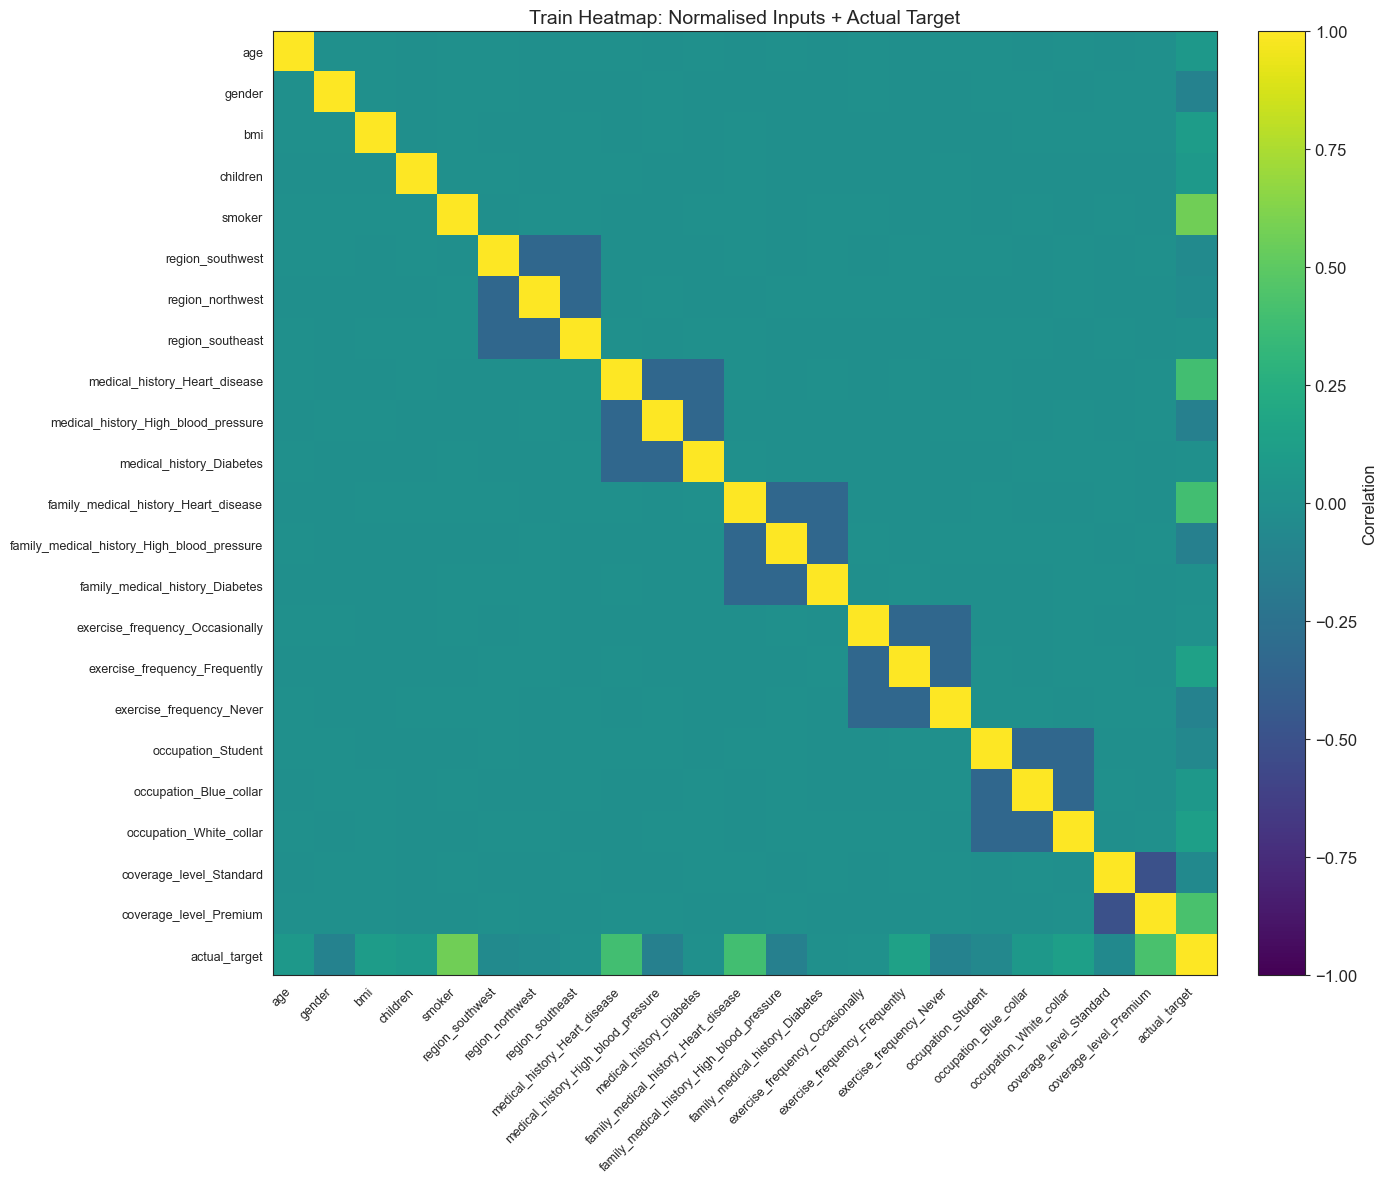

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_heatmap_train_actual.png


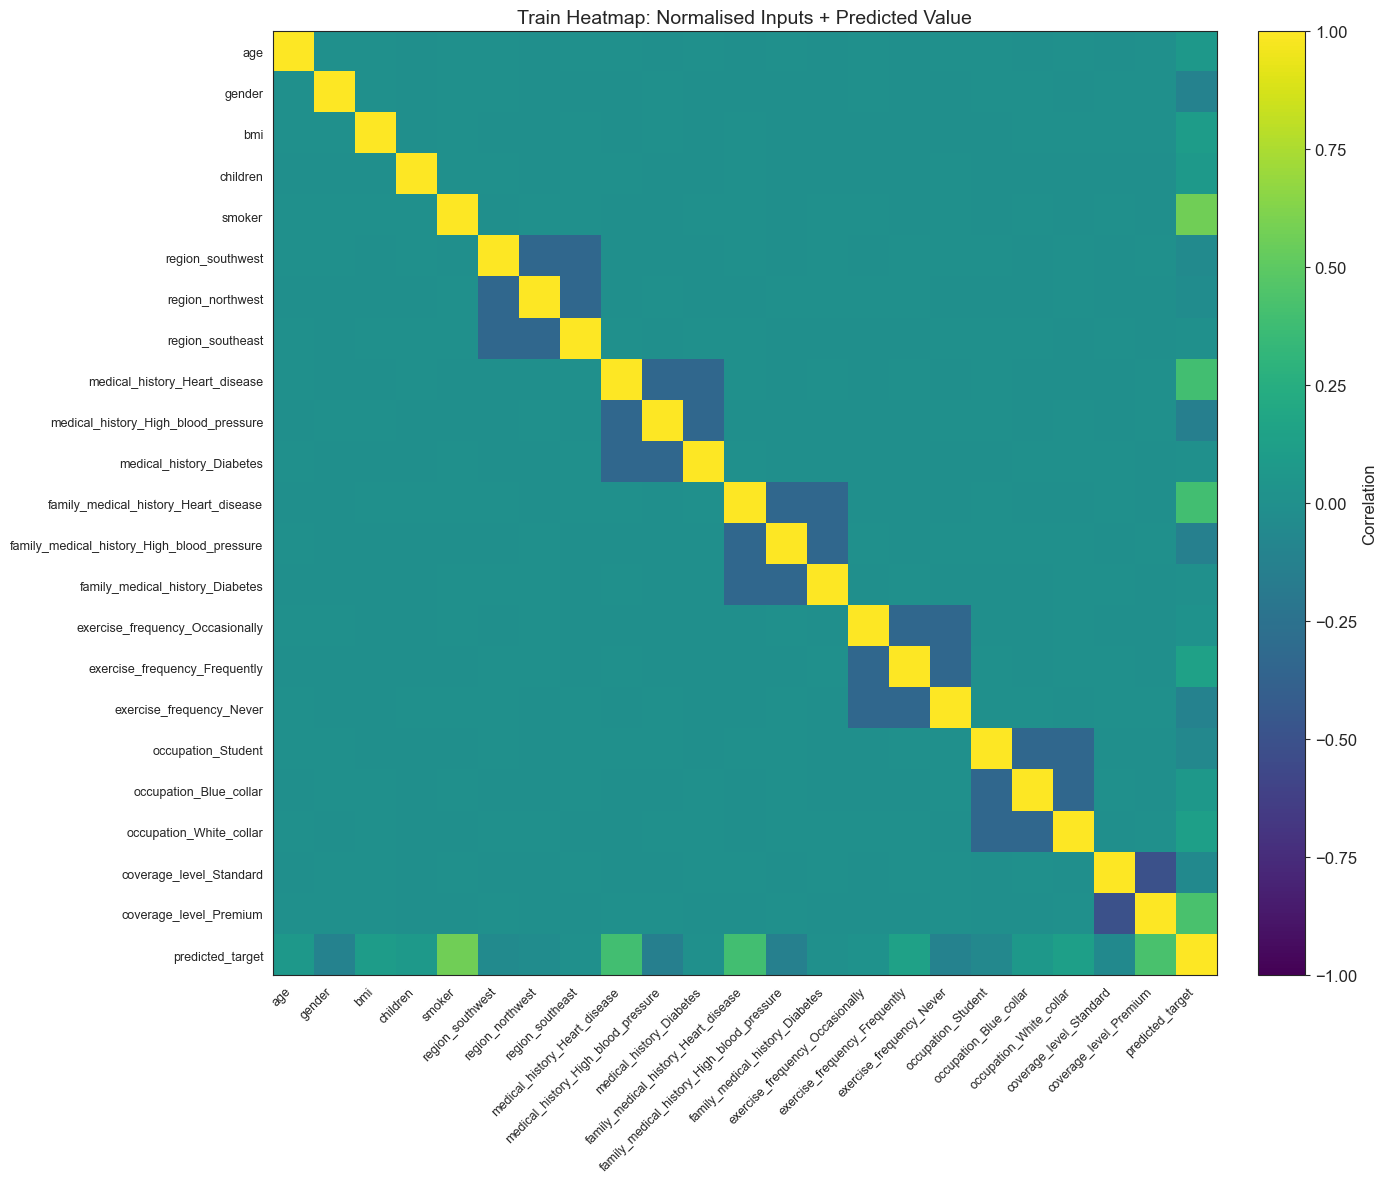

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_heatmap_train_predicted.png


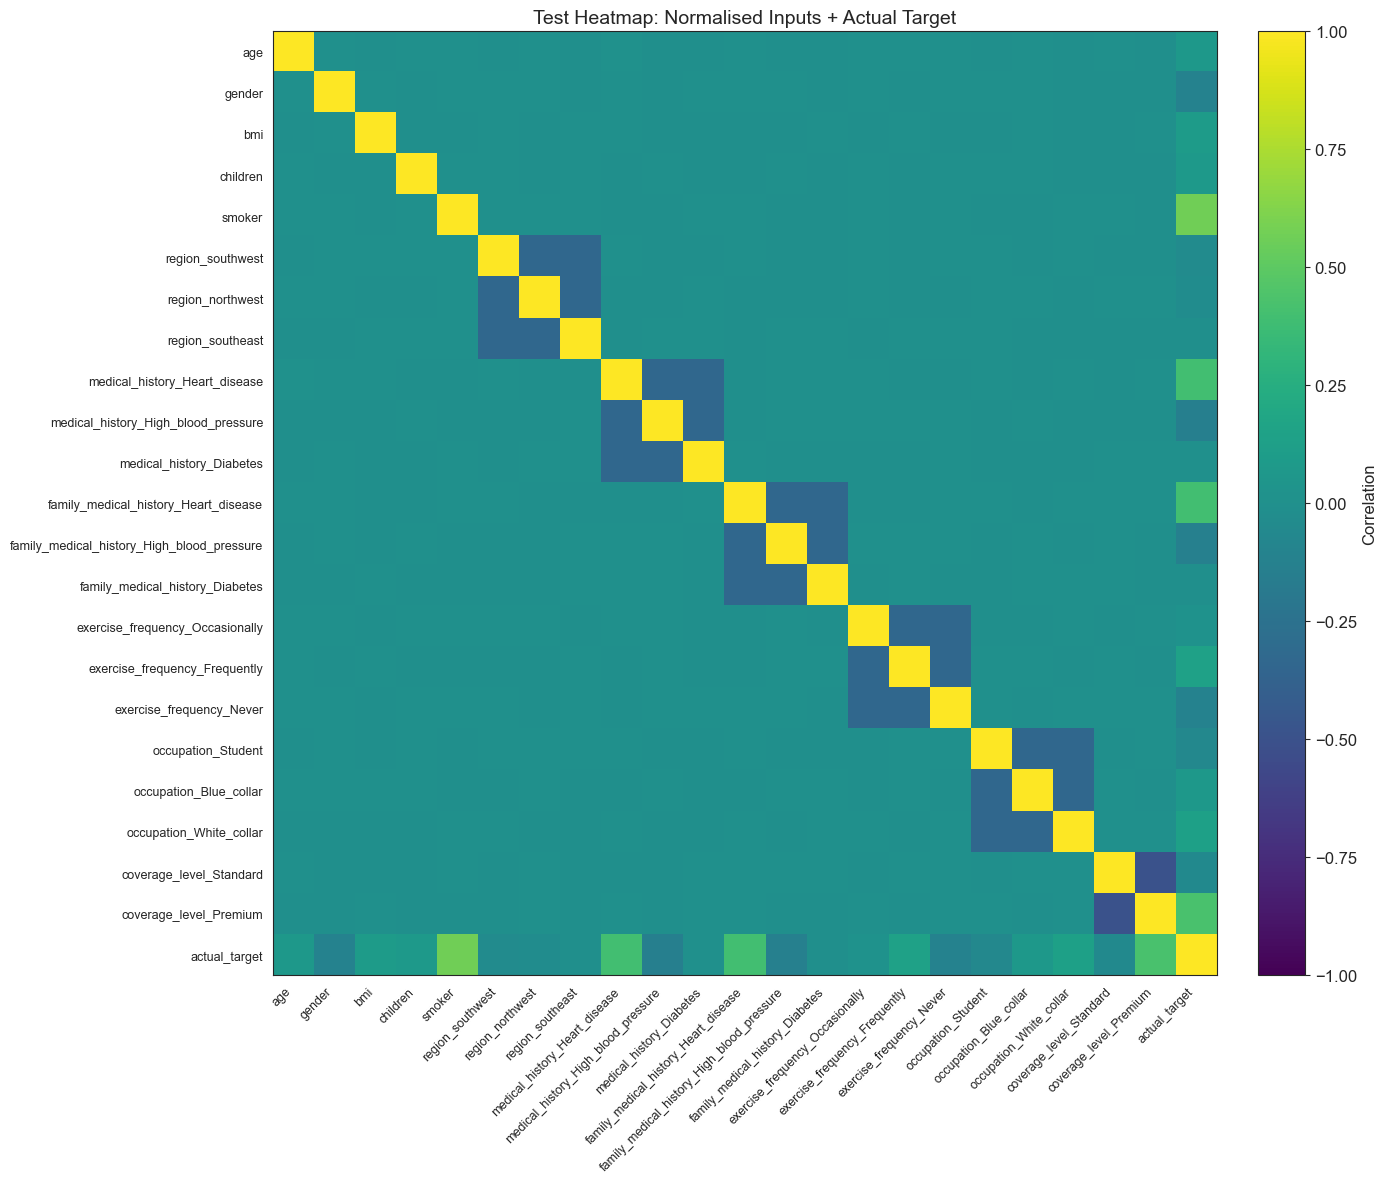

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_heatmap_test_actual.png


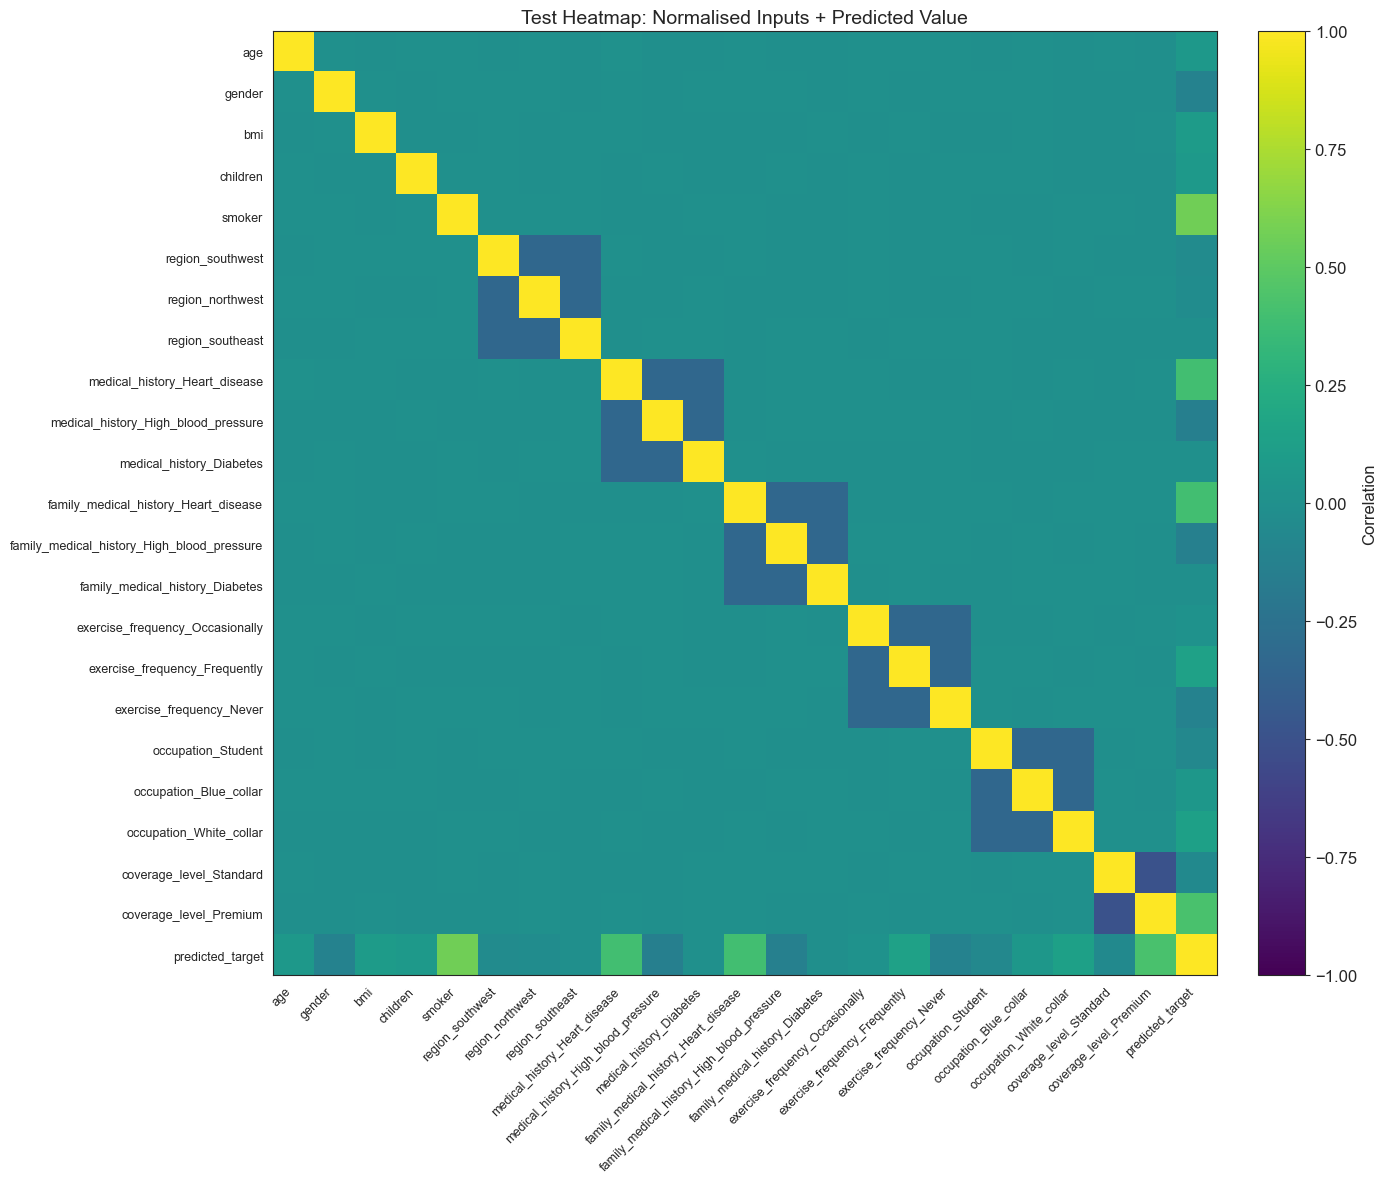

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_heatmap_test_predicted.png

TARGET CORRELATION COMPARISON (last row of each heatmap)
Feature                                   Train Act  Train Prd   Test Act   Test Prd
--------------------------------------------------------------------------------
age                                          0.0650     0.0657     0.0666     0.0675
gender                                      -0.1126    -0.1138    -0.1125    -0.1137
bmi                                          0.1058     0.1050     0.1011     0.1003
children                                     0.0781     0.0780     0.0741     0.0743
smoker                                       0.5665     0.5675     0.5649     0.5659
region_southwest                            -0.0394    -0.0398    -0.0373    -0.0377
region_northwest                            -0.0270    -0.0256    -0.0286    -0.0271
region_southeast                             0.0016     0.0007    -0.0012    -0.00

In [30]:
# --- Helper: build DataFrame of normalised inputs + target column ---
def build_corr_df(X_norm, target_values, target_label):
    """Combine normalised inputs with a target column into a DataFrame."""
    df = pd.DataFrame(X_norm, columns=FEATURES)
    df[target_label] = target_values
    return df


# --- Helper: plot correlation heatmap matching the reference style ---
def plot_corr_heatmap(corr_matrix, title, save_name):
    """Plot a full correlation heatmap with viridis colourmap, fixed [-1, 1] range."""
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(corr_matrix.values, cmap='viridis', vmin=-1, vmax=1, aspect='auto')
    
    # Tick labels
    n = len(corr_matrix)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(corr_matrix.index, fontsize=9)
    
    # Colourbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Correlation')
    
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR + save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_DIR}{save_name}')


# --- Heatmap 1: Train, Actual Target ---
df_train_act = build_corr_df(X_train, y_act_train, 'actual_target')
corr_train_act = df_train_act.corr()
plot_corr_heatmap(
    corr_train_act,
    title='Train Heatmap: Normalised Inputs + Actual Target',
    save_name='fig_heatmap_train_actual.png'
)

# --- Heatmap 2: Train, Predicted Value ---
df_train_prd = build_corr_df(X_train, y_prd_train, 'predicted_target')
corr_train_prd = df_train_prd.corr()
plot_corr_heatmap(
    corr_train_prd,
    title='Train Heatmap: Normalised Inputs + Predicted Value',
    save_name='fig_heatmap_train_predicted.png'
)

# --- Heatmap 3: Test, Actual Target ---
df_test_act = build_corr_df(X_test, y_act_test, 'actual_target')
corr_test_act = df_test_act.corr()
plot_corr_heatmap(
    corr_test_act,
    title='Test Heatmap: Normalised Inputs + Actual Target',
    save_name='fig_heatmap_test_actual.png'
)

# --- Heatmap 4: Test, Predicted Value ---
df_test_prd = build_corr_df(X_test, y_prd_test, 'predicted_target')
corr_test_prd = df_test_prd.corr()
plot_corr_heatmap(
    corr_test_prd,
    title='Test Heatmap: Normalised Inputs + Predicted Value',
    save_name='fig_heatmap_test_predicted.png'
)

# --- Print target correlation comparison ---
print('\n' + '=' * 70)
print('TARGET CORRELATION COMPARISON (last row of each heatmap)')
print('=' * 70)
print(f'{"Feature":<40} {"Train Act":>10} {"Train Prd":>10} {"Test Act":>10} {"Test Prd":>10}')
print('-' * 80)
for feat in FEATURES:
    print(f'{feat:<40} {corr_train_act.loc["actual_target", feat]:>10.4f} '
          f'{corr_train_prd.loc["predicted_target", feat]:>10.4f} '
          f'{corr_test_act.loc["actual_target", feat]:>10.4f} '
          f'{corr_test_prd.loc["predicted_target", feat]:>10.4f}')

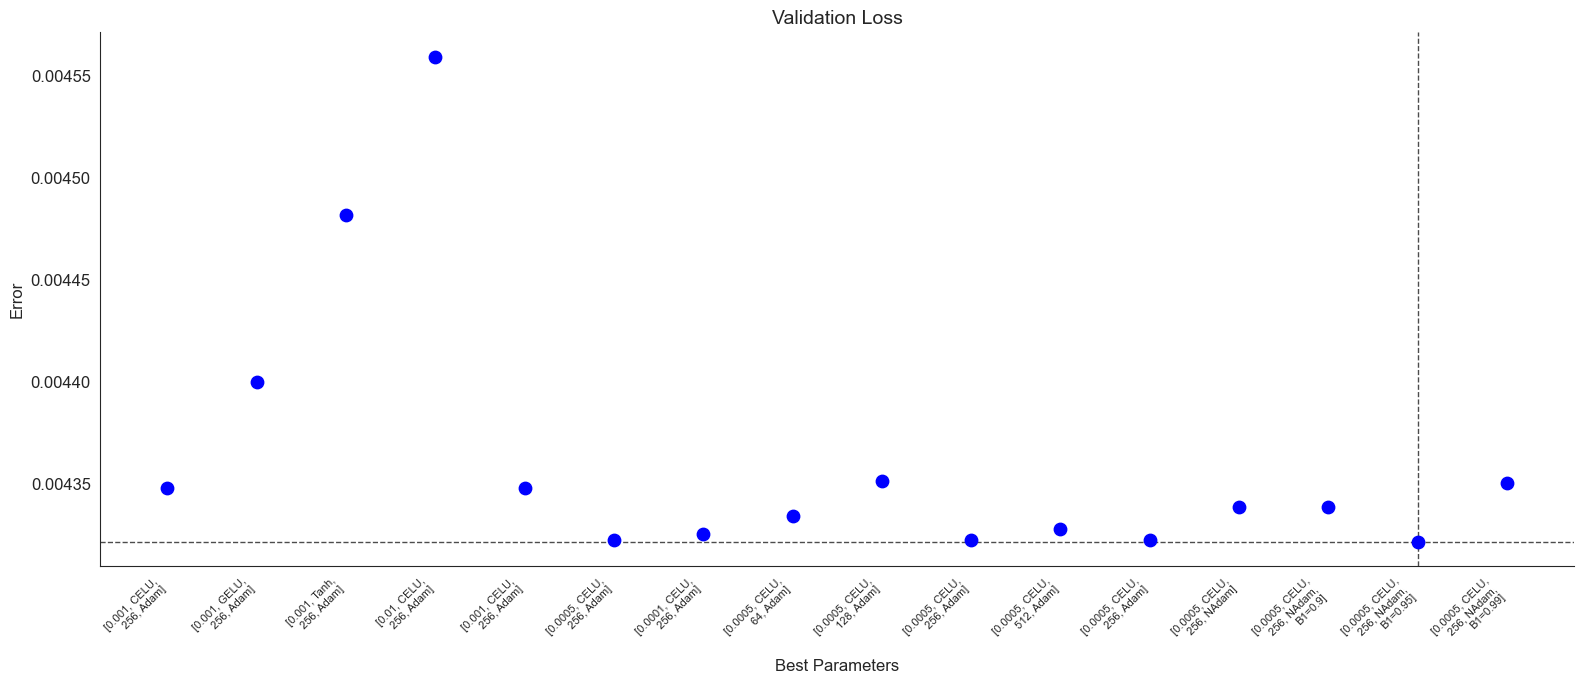

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_validation_loss_hyperparameters.png

Best configuration: [0.0005, CELU, 256, NAdam, B1=0.95]
Minimum validation loss: 0.004322


In [31]:
# Collect all configurations and their best validation losses across all phases
config_labels = []
config_val_losses = []

# Phase 1: Activation (lr=0.001, bs=256, Adam)
for act_name, res in phase1_results.items():
    idx = res['val_epochs'].index(res['best_epoch'])
    config_labels.append(f'[0.001, {act_name},\n256, Adam]')
    config_val_losses.append(res['val_losses'][idx])

# Phase 2: Learning Rate (best_activation, bs=256, Adam)
for lr_label, res in phase2_results.items():
    idx = res['val_epochs'].index(res['best_epoch'])
    config_labels.append(f'[{lr_label}, {best_activation},\n256, Adam]')
    config_val_losses.append(res['val_losses'][idx])

# Phase 3: Batch Size (best_activation, best_lr, Adam)
for bs_label, res in phase3_results.items():
    idx = res['val_epochs'].index(res['best_epoch'])
    config_labels.append(f'[{best_lr}, {best_activation},\n{bs_label}, Adam]')
    config_val_losses.append(res['val_losses'][idx])

# Phase 4: Optimiser (best_activation, best_lr, best_bs)
for opt_name, res in phase4_results.items():
    idx = res['val_epochs'].index(res['best_epoch'])
    config_labels.append(f'[{best_lr}, {best_activation},\n{best_bs}, {opt_name}]')
    config_val_losses.append(res['val_losses'][idx])

# Phase 5: Momentum (best_activation, best_lr, best_bs, best_optimiser)
for mom_label, res in phase5_results.items():
    idx = res['val_epochs'].index(res['best_epoch'])
    betas_val = momentum_candidates[mom_label]
    config_labels.append(f'[{best_lr}, {best_activation},\n{best_bs}, {best_optimiser_name},\nB1={betas_val[0]}]')
    config_val_losses.append(res['val_losses'][idx])

# Scatter plot with dashed crosshair at the minimum
fig, ax = plt.subplots(figsize=(16, 7))

x_pos = list(range(len(config_labels)))
ax.scatter(x_pos, config_val_losses, color='blue', s=80, zorder=5)

# Dashed lines marking the best configuration (minimum validation loss)
min_loss = min(config_val_losses)
min_idx = config_val_losses.index(min_loss)
ax.axhline(y=min_loss, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=min_idx, color='black', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(config_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Best Parameters')
ax.set_ylabel('Error')
ax.set_title('Validation Loss')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_validation_loss_hyperparameters.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {FIG_DIR}fig_validation_loss_hyperparameters.png')
print(f'\nBest configuration: {config_labels[min_idx].replace(chr(10), " ")}')
print(f'Minimum validation loss: {min_loss:.6f}')

### Figure 6: Training and Validation Losses Over Epochs

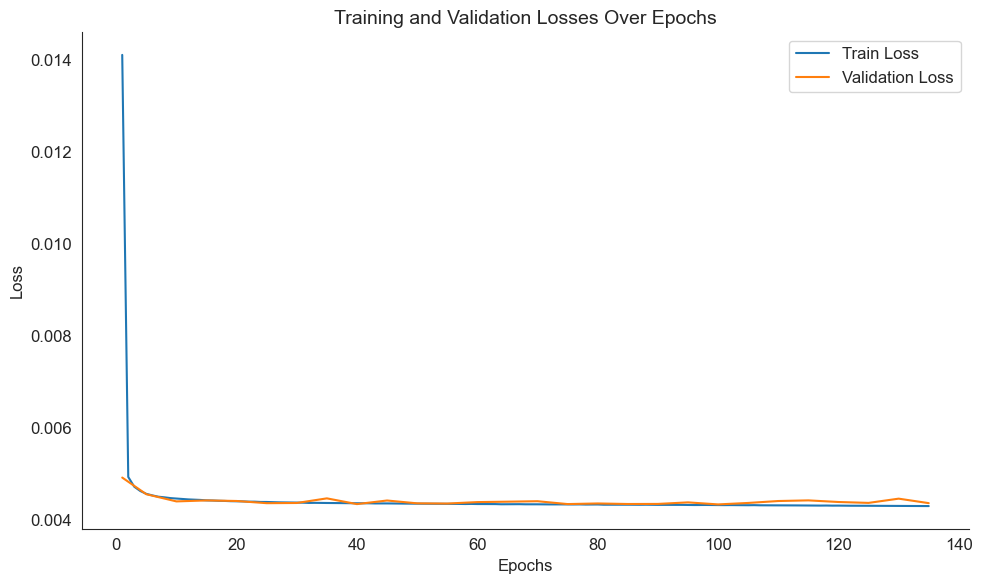

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_train_val_losses_epochs.png


In [32]:
# Training and validation losses over epochs (final model)
fig, ax = plt.subplots(figsize=(10, 6))

epochs_all = range(1, len(final_result['train_losses']) + 1)

# Training loss (recorded every epoch)
ax.plot(epochs_all, final_result['train_losses'],
        label='Train Loss', color='tab:blue', linewidth=1.5)

# Validation loss (recorded at val_epochs, connected with line)
ax.plot(final_result['val_epochs'], final_result['val_losses'],
        label='Validation Loss', color='tab:orange', linewidth=1.5)

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Losses Over Epochs')
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_train_val_losses_epochs.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_train_val_losses_epochs.png')

## 14. Save Final Model and Standardisation Parameters

In [33]:
# Save the final model checkpoint
model_path = '/Users/baloyithabangbonganijunior/Downloads/chapter3_final_model.pth'

checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'architecture': {
        'input_dim': 22,
        'hidden_layers': [256, 128, 64, 32, 16],
        'activation': best_activation,
        'bias': False
    },
    'hyperparameters': {
        'learning_rate': best_lr,
        'batch_size': best_bs,
        'optimiser': best_optimiser_name,
        'betas': best_betas,
        'max_epochs': MAX_EPOCHS,
        'val_every': VAL_EVERY,
        'patience': PATIENCE,
        'seed': SEED,
        'best_epoch': final_result['best_epoch']
    },
    'standardisation': {
        'X_mean': X_mean,
        'X_std': X_std,
        'y_mean': float(y_mean),
        'y_std': float(y_std)
    },
    'features': FEATURES,
    'metrics': metrics,
    'training_history': {
        'train_losses': final_result['train_losses'],
        'val_epochs': final_result['val_epochs'],
        'val_losses': final_result['val_losses'],
        'train_r2s': final_result['train_r2s'],
        'val_r2s': final_result['val_r2s']
    }
}

torch.save(checkpoint, model_path)
print(f'Model checkpoint saved to: {model_path}')
print(f'Checkpoint keys: {list(checkpoint.keys())}')

Model checkpoint saved to: /Users/baloyithabangbonganijunior/Downloads/chapter3_final_model.pth
Checkpoint keys: ['model_state_dict', 'architecture', 'hyperparameters', 'standardisation', 'features', 'metrics', 'training_history']


## 15. Final Summary

In [34]:
print('=' * 70)
print('DNN TRAINING COMPLETE - FINAL SUMMARY')
print('=' * 70)
print()
print('Architecture: 22 -> 256 -> 128 -> 64 -> 32 -> 16 -> 1')
total_params = sum(p.numel() for p in final_model.parameters())
print(f'Parameters  : {total_params:,}')
print()
print('Best Hyperparameters:')
print(f'  Activation   : {best_activation}')
print(f'  Learning rate: {best_lr}')
print(f'  Batch size   : {best_bs}')
print(f'  Optimiser    : {best_optimiser_name}')
print(f'  Momentum     : B1={best_betas[0]}, B2={best_betas[1]}')
print(f'  Best epoch   : {final_result["best_epoch"]}')
print()
print('Performance (de-normalised, Rand scale):')
print(f'  {"Set":<12} {"R2":>8} {"RMSE (R)":>12} {"MAE (R)":>12}')
print(f'  {"-"*44}')
for set_name, m in metrics.items():
    print(f'  {set_name:<12} {m["R²"]:>8.4f} {m["RMSE"]:>12.2f} {m["MAE"]:>12.2f}')
print()
print('Figures generated:')
for fig_name in [
    'fig_phase1_activation_comparison.png',
    'fig_phase2_lr_comparison.png',
    'fig_phase3_batchsize_comparison.png',
    'fig_phase4_optimiser_comparison.png',
    'fig_phase5_momentum_comparison.png',
    'fig_training_validation_curves.png',
    'fig_actual_vs_predicted_sorted_train.png',
    'fig_actual_vs_predicted_sorted_test.png',
    'fig_violin_actual_vs_predicted.png',
    'fig_violin_residuals.png',
    'fig_residual_diagnostics.png',
    'fig_pca_train_actual.png',
    'fig_pca_train_predicted.png',
    'fig_pca_test_actual.png',
    'fig_pca_test_predicted.png',
    'fig_pca_loadings.png',
    'fig_heatmap_train_actual.png',
    'fig_heatmap_train_predicted.png',
    'fig_heatmap_test_actual.png',
    'fig_heatmap_test_predicted.png',
    'fig_validation_loss_hyperparameters.png',
    'fig_train_val_losses_epochs.png',
]:
    print(f'  - {fig_name}')
print()
print('Files saved:')
print(f'  - {model_path}')
print(f'  - {summary_path}')
print(f'  - {FIG_DIR}pca_loadings.csv')

DNN TRAINING COMPLETE - FINAL SUMMARY

Architecture: 22 -> 256 -> 128 -> 64 -> 32 -> 16 -> 1
Parameters  : 49,168

Best Hyperparameters:
  Activation   : CELU
  Learning rate: 0.0005
  Batch size   : 256
  Optimiser    : NAdam
  Momentum     : B1=0.9, B2=0.999
  Best epoch   : 85

Performance (de-normalised, Rand scale):
  Set                R2     RMSE (R)      MAE (R)
  --------------------------------------------
  Train          0.9957       289.42       250.08
  Validation     0.9957       290.88       251.30
  Test           0.9956       291.07       251.52

Figures generated:
  - fig_phase1_activation_comparison.png
  - fig_phase2_lr_comparison.png
  - fig_phase3_batchsize_comparison.png
  - fig_phase4_optimiser_comparison.png
  - fig_phase5_momentum_comparison.png
  - fig_training_validation_curves.png
  - fig_actual_vs_predicted_sorted_train.png
  - fig_actual_vs_predicted_sorted_test.png
  - fig_violin_actual_vs_predicted.png
  - fig_violin_residuals.png
  - fig_residual_diag